# 🎮 Deep RL Final Project — MiniGrid Environments

## Overview
In this project, you will train deep RL agents on two MiniGrid environments. You must implement the core algorithms yourself using concepts from class.

**Read first:** Follow the instructions in the accompanying PDF. This notebook defines the environment APIs and where you may edit.

## Learning objectives
- Implement deep RL from scratch.
- Design observation preprocessing and reward shaping.
- Evaluate performance with clear metrics and plots.
- Communicate results in a concise report.

## 🌍 The Two Environments
| Environment | Description | Actions | Goal |
|-------------|-------------|---------|------|
| **`SimpleGridEnv`** | 8×8 empty room | 3 (Left, Right, Forward) | Navigate to the green goal square |
| **`KeyDoorBallEnv`** | Two rooms with locked door | 5 (Left, Right, Forward, Pickup, Toggle) | Get key → Open door → Pick up ball → Reach goal |

## ✅ What You CAN Modify
- **Preprocessing** — Implement your own observation preprocessing function.
- **Reward shaping** — Modify rewards in each `step()` method (see `# TODO`).
- **Observation space** — Update `self.observation_space` to match preprocessing output.

## ❌ What You CANNOT Modify
- Grid layout and generation logic.
- Action spaces or termination conditions.
- Environment mechanics (door/key/ball rules).
- **No external RL libraries** for the core algorithm (you may use PyTorch/TensorFlow).

## 📦 Deliverables & Submission
**Submit:** (1) this notebook with your full code and outputs, and (2) a report formatted **as specified in the instructions PDF**.

## 🧪 Reproducibility checklist
- Set random seeds for Python, NumPy, and your DL framework.
- Document hyperparameters.

## 🧾 Academic integrity
- You may discuss ideas, but code and write-up must be your own.
- Cite any external resources (blog posts, papers, code snippets).
---

# Setup

## Installs and Imports

### Installs (run once if needed)

In [1]:
%%capture
!sudo apt-get update
!sudo apt-get install -y xvfb ffmpeg freeglut3-dev
!pip install imageio
!pip install pyvirtualdisplay
!pip install gymnasium
!pip install minigrid
!pip install pygame
!pip install torch opencv-python pandas


### Imports

In [2]:
# 1. Future Imports (Must be first)
from __future__ import annotations

# 2. Standard Library Imports
import base64
import copy
import random

# 3. Third-Party Data & Visualization Imports
import imageio
import matplotlib.pyplot as plt
import numpy as np
import IPython
from IPython.display import HTML
import pyvirtualdisplay

# 4. Gymnasium Imports
import gymnasium as gym
from gymnasium import spaces

# 5. Minigrid Imports
from minigrid.core.constants import COLOR_NAMES
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Door, Goal, Key, Lava, Wall, Ball
from minigrid.minigrid_env import MiniGridEnv as BaseMiniGridEnv

# --- Configuration ---

# Configure Matplotlib for Notebook Environment
%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

### Display utils
The cell below contains the video display configuration. No need to make changes here.

In [3]:
def embed_mp4(filename):
  """Embeds an mp4 file in the notebook."""
  video = open(filename,'rb').read()
  b64 = base64.b64encode(video)
  tag = '''
  <video width="640" height="480" controls>
    <source src="data:video/mp4;base64,{0}" type="video/mp4">
  Your browser does not support the video tag.
  </video>'''.format(b64.decode())

  return IPython.display.HTML(tag)

display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()

# Environments

> ⚠️ **Important**
>
> The two environments below are **fixed**—do not modify grid layout, action spaces, or termination conditions.
>
> **You may modify only:**
> 1. **Observation space** — set `self.observation_space` to match your preprocessing output (see `# TODO`).
> 2. **Reward shaping** — edit reward logic inside `step()` (see `# TODO`).
>
> Look for the clearly marked sections in each environment class.

In [4]:
# =============================================================================
# ENVIRONMENT 1: SIMPLE GRID (Empty Room)
# =============================================================================
class SimpleGridEnv(BaseMiniGridEnv):
    """
    A simple grid environment with no obstacles inside, just outer walls.
    The agent and goal positions are randomized at each reset.

    Actions:
        0: Turn Left
        1: Turn Right
        2: Move Forward
    """
    def __init__(
        self,
        size=10,
        max_steps=1000,
        render_mode="rgb_array",
        preprocess=None,
        **kwargs,
    ):

        # Define a static mission string (not used by the agent typically)
        mission_space = MissionSpace(mission_func=self._gen_mission)


        super().__init__(
            mission_space=mission_space,
            grid_size=size,
            see_through_walls=True,
            max_steps=max_steps,
            render_mode=render_mode,
            highlight=False,
            **kwargs,
        )
        # Discrete actions: 0: Turn Left, 1: Turn Right, 2: Move Forward
        self.action_space = spaces.Discrete(3)

        # ╔═════════════════════════════════════════════════════════════════════╗
        # ║  ✅ STUDENT TODO: Update observation_space to match preprocessing   ║
        # ╚═════════════════════════════════════════════════════════════════════╝
        self.observation_space = spaces.Box(
            low=0,
            high=255,
            shape=(84, 84, 1),
            dtype=np.uint8
        )
        # ╔═════════════════════════════════════════════════════════════════════╗
        # ║                     END OF EDITABLE SECTION                         ║
        # ╚═════════════════════════════════════════════════════════════════════╝

        # Preprocessing function for observations
        self.preprocess = preprocess if preprocess is not None else lambda x: x
        self.walls_init = []
        # Default goal and agent starting position (overwritten in _gen_grid)
        self.goal_pos = (self.width - 2, self.height - 2)
        self.agent_start_pos = (1, 1)
        self.agent_start_dir = 0


    # ╔═════════════════════════════════════════════════════════════════════════╗
    # ║  ⛔ DO NOT MODIFY: Core environment methods below                       ║
    # ╚═════════════════════════════════════════════════════════════════════════╝

    @staticmethod
    def _gen_mission():
        return "grand mission"

    def _get_obs(self, obs=None):
        """Returns the current observation after applying preprocessing."""
        obs = self.get_frame(highlight=False, tile_size=32)
        return self.preprocess(obs)

    def reset(self, *, seed=None, options=None):
        # 1. Randomize agent starting parameters before generating the grid
        self.agent_start_pos = (random.randint(1, 6), random.randint(1, 6))
        self.agent_start_dir = random.choice([0, 1, 2, 3])
        # 2. Call parent reset, which internally calls _gen_grid()
        obs, info = super().reset(seed=seed, options=options)
        # 3. Return the preprocessed observation
        return self._get_obs(obs), info

    def _gen_grid(self, width, height):
        """Procedurally generates the grid layout: walls, goal, and agent."""
        self.grid = Grid(width, height)

        # 1. Create the outer boundary walls
        self.grid.wall_rect(0, 0, width, height)

        # 2. Place internal walls (if any defined in self.walls_init)
        for column, row in self.walls_init:
            self.grid.set(column, row, Wall())

        # 3. Randomize Goal Position (Top-Right, Bottom-Right, Bottom-Left corners roughly)
        self.goal_pos = random.choice([(8,1), (8,8), (1,8)])
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # 4. Place Agent
        self.agent_pos = self.agent_start_pos
        self.agent_dir = self.agent_start_dir

        self.mission = "grand mission"

    # ╔═════════════════════════════════════════════════════════════════════════╗
    # ║  ✅ STUDENT TODO: Modify reward shaping below                           ║
    # ╚═════════════════════════════════════════════════════════════════════════╝
    def step(self, action):
        """
        Standard step function.

        Current reward scheme (sparse):
            - +1.0 when reaching the goal (terminated=True)
            - 0.0 otherwise

        💡 You can add reward shaping here
        """
        obs, reward, terminated, truncated, info = super().step(action)

        # ----- REWARD SHAPING: EDIT BELOW THIS LINE -----
        # fetcth reward config if it exists
        reward_config = getattr(self, "reward_shaping", {})

        # goal reward
        if terminated:
            reward = reward_config.get("goal", 1.0)

        # step penalty
        reward -= reward_config.get("step", 0.0)

        # ----- REWARD SHAPING: EDIT ABOVE THIS LINE -----

        return self._get_obs(obs), reward, terminated, truncated, info
    # ╔═════════════════════════════════════════════════════════════════════════╗
    # ║                     END OF EDITABLE SECTION                             ║
    # ╚═════════════════════════════════════════════════════════════════════════╝

In [5]:
# =============================================================================
# ENVIRONMENT 2: KEY-DOOR WITH BALL PICKUP
# =============================================================================
class KeyDoorBallEnv(BaseMiniGridEnv):
    """
    Grid environment with two rooms separated by a locked door.

    Task sequence:
        1. Pick up key -> 2. Unlock door -> 3. Pick up ball -> 4. Reach goal

    Actions:
        0: Turn Left
        1: Turn Right
        2: Move Forward
        3: Pick Up
        4: Toggle (open/close door)
    """
    def __init__(
        self,
        size=10,
        max_steps=1000,
        render_mode="rgb_array",
        partition_col=3,
        require_ball_pickup=True,
        preprocess=None,
        **kwargs,
    ):
        self.agent_start_pos = (1, 1)
        self.agent_start_dir = 0
        self.partition_col = partition_col
        self.walls_init = []
        self.inventory = []
        self.require_ball_pickup = require_ball_pickup
        self.preprocess = preprocess if preprocess is not None else lambda x: x

        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space,
            grid_size=size,
            see_through_walls=True,
            max_steps=max_steps,
            render_mode=render_mode,
            highlight=False,
            **kwargs,
        )

        # 5 actions: left, right, forward, pickup, toggle
        self.action_space = spaces.Discrete(5)

        # ╔═════════════════════════════════════════════════════════════════════╗
        # ║  ✅ STUDENT TODO: Update observation_space to match preprocessing   ║
        # ╚═════════════════════════════════════════════════════════════════════╝
        self.observation_space = spaces.Box(
            low=0,
            high=255,
            shape=(84, 84, 3),
            dtype=np.uint8
        )
        # ╔═════════════════════════════════════════════════════════════════════╗
        # ║                     END OF EDITABLE SECTION                         ║
        # ╚═════════════════════════════════════════════════════════════════════╝

        # State tracking for reward shaping (you can use these in your reward logic)
        self.prev_key = False
        self.prev_door = False
        self.prev_ball = False

        # --- STUDENT ADDITION ---:
        # additional event tracking
        self.prev_action = None
        self.prev_pos = None
        self.has_opened_door = False
        self.has_crossed_door = False

    # ╔═════════════════════════════════════════════════════════════════════════╗
    # ║  ⛔ DO NOT MODIFY: Core environment methods below                       ║
    # ╚═════════════════════════════════════════════════════════════════════════╝

    @staticmethod
    def _gen_mission():
        return "Pick up the key to open the door, pick up the ball, then reach the goal"

    def _get_obs(self, obs=None):
        """Returns the current observation after applying preprocessing."""
        obs = self.get_frame(highlight=False, tile_size=32)
        return self.preprocess(obs)

    def reset(self, *, seed=None, options=None):
        # Reset state tracking
        self.prev_key = False
        self.prev_door = False
        self.prev_ball = False
        self.inventory = []

        # --- STUDENT ADDITION ---:
        # additional event tracking
        self.prev_action = None
        self.prev_pos = None
        self.has_opened_door = False
        self.has_crossed_door = False

        # Call parent reset, which internally calls _gen_grid()
        obs, info = super().reset(seed=seed, options=options)

        return self._get_obs(obs), info

    def _gen_grid(self, width, height):
        """Generate grid: walls, partition, door, key, ball, goal, agent."""
        # Grid with outer walls
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # Partition wall
        self.walls_init = [(self.partition_col, i) for i in range(height)]
        for col, row in self.walls_init:
            if 0 <= col < width and 0 <= row < height:
                self.grid.set(col, row, Wall())

        # Key in left room
        self.key_pos = (
            random.choice(range(1, self.partition_col)),
            random.choice(range(2, height - 1))
        )
        self.grid.set(self.key_pos[0], self.key_pos[1], Key(COLOR_NAMES[0]))

        # Door in partition
        door_y = random.choice(range(1, height - 1))
        self.door_pos = (self.partition_col, door_y)
        self.env_door = Door(COLOR_NAMES[0], is_locked=True)
        self.grid.set(self.door_pos[0], self.door_pos[1], self.env_door)

        # Goal
        self.goal_pos = (8, 8)
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # Ball in right room (if required)
        if self.require_ball_pickup:
            right_x = range(self.partition_col + 2, width - 2)
            right_y = range(1, height - 1)
            while True:
                ball_x = random.choice(list(right_x))
                ball_y = random.choice(list(right_y))
                self.ball_pos = (ball_x, ball_y)
                if self.ball_pos != self.goal_pos:
                    break

            self.grid.set(ball_x, ball_y, Ball(COLOR_NAMES[1]))

        # Agent
        self.agent_pos = self.agent_start_pos
        self.agent_dir = self.agent_start_dir

    def try_pickup_ball(self):
        """Pick up ball in front and add to inventory."""
        obj = self.grid.get(self.front_pos[0], self.front_pos[1])
        if isinstance(obj, Ball):
            self.grid.set(self.front_pos[0], self.front_pos[1], None)
            self.inventory.append(obj)

    # ╔═════════════════════════════════════════════════════════════════════════╗
    # ║  ✅ STUDENT TODO: Modify reward shaping below                           ║
    # ╚═════════════════════════════════════════════════════════════════════════╝
    def step(self, action):
        """
        Step function with sparse reward.

        Available helper methods for reward shaping:
            - self.is_carrying_key()  : Returns True if agent has the key
            - self.is_carrying_ball() : Returns True if agent has the ball
            - self.is_door_open()     : Returns True if door is open
            - self.prev_key           : Key status before this step
            - self.prev_door          : Door status before this step
            - self.prev_ball          : Ball status before this step

        Current reward scheme (sparse):
            - +1.0 for reaching goal with ball
            - 0.0 otherwise

        💡 You can add reward shaping here
        """
        # Map action 4 to toggle (internal MiniGrid uses 5 for toggle)
        if action == 4:
            action = 5

        # Track previous state for reward shaping
        self.prev_key = self.is_carrying_key()
        self.prev_door = self.is_door_open()
        self.prev_ball = self.is_carrying_ball()

        # Handle ball pickup
        if action == 3:
            self.try_pickup_ball()

        # Standard step
        obs, reward, terminated, truncated, info = super().step(action)

        # Goal only counts if ball is picked up (when required)
        terminated = terminated and (not self.require_ball_pickup or self.is_carrying_ball())

        # ----- REWARD SHAPING: EDIT BELOW THIS LINE -----

        # fetcth reward config if it exists
        reward_config = getattr(self, "reward_shaping", {})
        reward = 0.0

        # milestone rewards:
        # key pickuop reward (before: no key, now: have key)
        if not self.prev_key and self.is_carrying_key():
            reward += reward_config.get("key", 0.5)

        # door opened reward (before: had key + door closed, now: door open)
        if (self.prev_key) and (not self.prev_door) and (self.is_door_open()) and (not self.has_opened_door):
            reward += reward_config.get("door", 0.5)
            self.has_opened_door = True

        # room-crossing reward
        current_in_right_room = self.agent_pos[0] > self.partition_col
        prev_in_right_room = (self.prev_pos[0] > self.partition_col) if self.prev_pos is not None else False
        if (not prev_in_right_room) and (current_in_right_room) and (not self.has_crossed_door):
            reward += reward_config.get("room_crossing", 1.0)
            self.has_crossed_door = True

        # ball pickup reward (before: no ball, now: have ball)
        if not self.prev_ball and self.is_carrying_ball():
            reward += reward_config.get("ball", 0.5)

        # goal reward
        if terminated:
            reward += reward_config.get("goal", 2.0)

        # penalties:
        # failed interaction penalties (idle pickup/toggle)
        pickup_succeeded =  ((not self.prev_key)  and self.is_carrying_key()) or \
                            ((not self.prev_ball) and self.is_carrying_ball())
        toggle_succeeded = (self.prev_door != self.is_door_open())

        # idle pickup
        if action == 3 and (not pickup_succeeded):
            reward -= reward_config.get("failed_pickup_penalty", 0.0)

        # idle toggle
        if action == 5 and (not toggle_succeeded):
            reward -= reward_config.get("failed_toggle_penalty", 0.0)

        # step penalty
        reward -= reward_config.get("step", 0.001)

        # store current info for event tracking in next step
        self.prev_action = action
        self.prev_pos = tuple(self.agent_pos)

        # ----- REWARD SHAPING: EDIT ABOVE THIS LINE -----

        return self._get_obs(obs), reward, terminated, truncated, info
    # ╔═════════════════════════════════════════════════════════════════════════╗
    # ║                     END OF EDITABLE SECTION                             ║
    # ╚═════════════════════════════════════════════════════════════════════════╝

    # ╔═════════════════════════════════════════════════════════════════════════╗
    # ║  ⛔ DO NOT MODIFY: State getter methods (use these in reward shaping)   ║
    # ╚═════════════════════════════════════════════════════════════════════════╝

    def is_carrying_key(self):
        """Check if agent has key (in hand or inventory)."""
        key_in_hand = self.carrying and isinstance(self.carrying, Key)
        key_in_inventory = any(isinstance(item, Key) for item in self.inventory)
        return key_in_hand or key_in_inventory

    def is_carrying_ball(self):
        """Check if agent has ball (in hand or inventory)."""
        ball_in_hand = self.carrying and isinstance(self.carrying, Ball)
        ball_in_inventory = any(isinstance(item, Ball) for item in self.inventory)
        return ball_in_hand or ball_in_inventory

    def is_door_open(self):
        """Returns True if the door is open."""
        if hasattr(self, 'env_door'):
            return self.env_door.is_open
        return False

# Preprocessing Method

> 💡 **Student task:** Implement your own preprocessing function below.
>
> Your preprocessing function should:
> 1. Take a raw RGB image (320×320×3) as input.
> 2. Return a processed observation that **exactly matches** your `observation_space` (shape, dtype, value range).
>
> Common preprocessing techniques:
> - Crop edges to remove borders
> - Convert to grayscale
> - Resize to smaller dimensions
> - Normalize pixel values
>
> **Reminder:** Update `self.observation_space` in both environment classes to match your output.

In [6]:
import cv2

# Example Preprocessing Function
def pre_process(img):
    """
    Preprocess raw RGB observation from the environment.

    Input:  RGB image (320, 320, 3)
    Output: Grayscale image (320, 320, 1)
    """
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (84, 84), interpolation=cv2.INTER_AREA)
    return np.expand_dims(resized, axis=-1) # (84, 84) -> (84, 84, 1)


def pre_process_keydoorball(img):
    """
    Preprocess raw RGB observation from the environment.

    Input:  RGB image (320, 320, 3)
    Output: RGB image (320, 320, 3)
    """
    resized = cv2.resize(img, (84, 84), interpolation=cv2.INTER_AREA)
    return resized.astype(np.uint8)

# 🔍 Environment Examples & Exploration
Run the cells below to understand each environment before implementing your solution.
Use these quick tests to verify preprocessing output shape and rendering.

## Environment 1: SimpleGridEnv (Empty Room)

**Task**: Navigate to the green goal square in an empty 8×8 room.

| Property | Value |
|----------|-------|
| Grid Size | 8×8 |
| Agent Start | Random position (1-6, 1-6) |
| Agent Direction | Random (0-3) |
| Goal Position | Random: (8,1), (1,8), or (8,8) |
| Actions | 0: Turn Left, 1: Turn Right, 2: Move Forward |
| Sparse Reward | +1.0 on reaching goal, 0.0 otherwise |

### Quick Test

=== SimpleGridEnv ===
Action space:       Discrete(3)
Number of actions:  3
Observation space:  Box(0, 255, (84, 84, 1), uint8)  (ensure it matches preprocessing output)
Observation shape:  (84, 84, 1)
Agent direction:    3
Agent position:     (1, 5)
Goal position:      (1, 8)


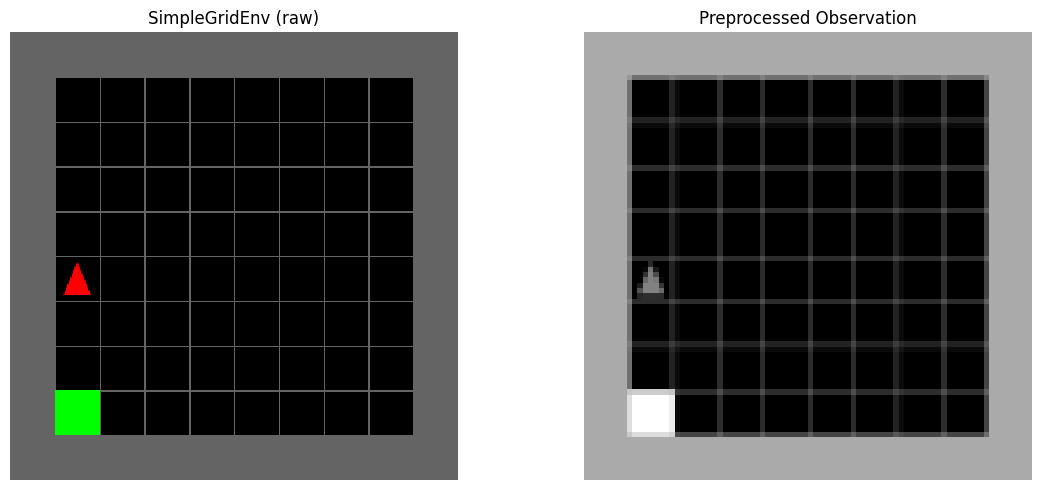

In [7]:
# Initialize environment with preprocessing
env = SimpleGridEnv(max_steps=100, preprocess=pre_process)
obs = env.reset()[0]

print("=== SimpleGridEnv ===")
print(f"Action space:       {env.action_space}")
print(f"Number of actions:  {env.action_space.n}")
print(f"Observation space:  {env.observation_space}  (ensure it matches preprocessing output)")
print(f"Observation shape:  {obs.shape}")
print(f"Agent direction:    {env.agent_dir}")
print(f"Agent position:     {env.agent_pos}")
print(f"Goal position:      {env.goal_pos}")

# Side-by-side view of raw and preprocessed observations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(env.render())
axes[0].set_title("SimpleGridEnv (raw)")
axes[0].axis("off")
axes[1].imshow(obs.squeeze(), cmap="gray")
axes[1].set_title("Preprocessed Observation")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Environment 2: KeyDoorBallEnv (Key-Door-Ball Task)

**Task**: Complete a multi-step objective: Key → Door → Ball → Goal

| Property | Value |
|----------|-------|
| Grid Size | 8×8 (two rooms) |
| Partition Wall | Column 3 |
| Key Location | Left room (random) |
| Door Location | In partition wall (random row) |
| Ball Location | Right room (random) |
| Goal Position | Fixed at (8, 8) |
| Actions | 0: Left, 1: Right, 2: Forward, 3: Pickup, 4: Toggle |

**Sequence**: Pick up key → Open door → Enter right room → Pick up ball → Reach goal

**Helper Methods** (use in reward shaping):
- `is_carrying_key()` — True if agent has the key
- `is_carrying_ball()` — True if agent has the ball
- `is_door_open()` — True if door is open

### Quick Test

=== KeyDoorBallEnv ===
Action space:       Discrete(5)
Number of actions:  5
Observation space:  Box(0, 255, (84, 84, 3), uint8)  (ensure it matches preprocessing output)
Observation shape:  (84, 84, 1)
Agent direction:    0
Agent position:     (1, 1)
Goal position:      (8, 8)
Carrying key:       False
Door open:          False
Carrying ball:      False


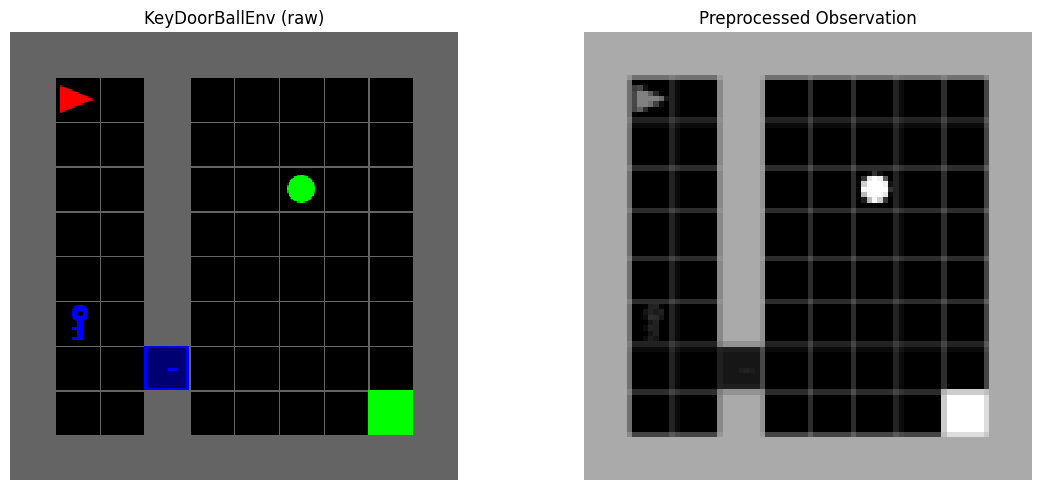

In [8]:
# Initialize environment
env = KeyDoorBallEnv(max_steps=5000, preprocess=pre_process)
obs = env.reset()[0]

print("=== KeyDoorBallEnv ===")
print(f"Action space:       {env.action_space}")
print(f"Number of actions:  {env.action_space.n}")
print(f"Observation space:  {env.observation_space}  (ensure it matches preprocessing output)")
print(f"Observation shape:  {obs.shape}")
print(f"Agent direction:    {env.agent_dir}")
print(f"Agent position:     {env.agent_pos}")
print(f"Goal position:      {env.goal_pos}")
print(f"Carrying key:       {env.is_carrying_key()}")
print(f"Door open:          {env.is_door_open()}")
print(f"Carrying ball:      {env.is_carrying_ball()}")

# Side-by-side view of raw and preprocessed observations
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(env.render())
axes[0].set_title("KeyDoorBallEnv (raw)")
axes[0].axis("off")
axes[1].imshow(obs.squeeze(), cmap="gray")
axes[1].set_title("Preprocessed Observation")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [9]:
# Random action rollout + video
max_steps = 100
env = KeyDoorBallEnv(max_steps=max_steps, preprocess=pre_process)
num_actions = env.action_space.n
obs = env.reset()[0]
video_filename = "/content/KeyDoorBallEnv_random.mp4"

with imageio.get_writer(video_filename, fps=10) as video:
    obs, _ = env.reset()
    done = False
    total_reward = 0
    for step in range(max_steps):
        action = random.randint(0, num_actions - 1)
        obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        total_reward += reward
        video.append_data(env.render())
        if done:
            break

# Print episode summary
print("=== Episode Summary ===")
print(f"Steps:         {step + 1}")
print(f"Total reward:  {total_reward:.3f}")
print(f"Terminated:    {terminated}")
print(f"Truncated:     {truncated}")
print()
print("=== Environment Status (End of Episode) ===")
print(f"Agent position:  {env.agent_pos}")
print(f"Carrying key:    {env.is_carrying_key()}")
print(f"Door open:       {env.is_door_open()}")
print(f"Carrying ball:   {env.is_carrying_ball()}")

embed_mp4(video_filename)

=== Episode Summary ===
Steps:         100
Total reward:  0.400
Terminated:    False
Truncated:     True

=== Environment Status (End of Episode) ===
Agent position:  (np.int64(1), np.int64(3))
Carrying key:    True
Door open:       False
Carrying ball:   False


# Your Code Below

#Imports

In [10]:
import copy
import csv
import json
import os
import random
import time
from abc import ABC, abstractmethod
from collections import deque
from datetime import timedelta
from functools import wraps
from typing import Dict, List, Tuple

import imageio
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
from torch import Tensor
from torch.nn import functional as F
import torch.optim as optim


#Constants

In [11]:
# Define constant paths for the project
SRC_DIR = "/content/src"
ROOT_DIR = "/content"

EPISODE_WINDOW_SIZE = 100

#Utils

In [12]:
def set_random_seed(seed: int) -> None:
    """
    Sets seed for random number generator
    - cmopatible with CPU/GPU
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True

def get_device() -> torch.device:
    """Returns the device that runs training (GPU/CPU)"""
    processor_type = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {processor_type}")
    return torch.device(processor_type)


# ** TIMER UTIL **
def timer(func):
    """
    Measures running time of decorated function
    :returns: (function output, time delta)
    """
    @wraps(func)
    def wrapper(*args, **kwargs) -> Tuple[object, float]:
        # sync CPU & GPU if using cuda
        if torch.cuda.is_available():
            torch.cuda.synchronize()

        start_time = time.perf_counter()
        result = func(*args, **kwargs)      # output of decorated function

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        end_time = time.perf_counter()
        time_delta = (end_time - start_time)
        # print(f"Function {func.__name__} took {time_delta}")
        return result, time_delta
    return wrapper


class MetricsHandler:
    """Helper class to track/print/log metrics """

    def __init__(self, num_episodes: int, window_size: int = None):
        self.num_episodes = num_episodes
        self.window = window_size
        if window_size:
            self.rewards = deque(maxlen=window_size)
            self.step_counts = deque(maxlen=window_size)
            self.success_counts = deque(maxlen=window_size)
        else:
            self.rewards = []
            self.step_counts = []
            self.success_counts = []

    def update(self, reward: float, steps: int, success: bool):
        self.rewards.append(reward)
        self.step_counts.append(steps)
        self.success_counts.append(int(success))

    @property
    def avg_reward(self) -> float:
        return sum(self.rewards) / len(self.rewards) if self.rewards else 0.0

    @property
    def avg_steps(self) -> float:
        return sum(self.step_counts) / len(self.step_counts) if self.step_counts else 0.0

    @property
    def success_rate(self) -> float:
        return sum(self.success_counts) / len(self.success_counts) if self.success_counts else 0.0

    def get_inference_metrics(self) -> Dict:
        return {
            "inference_episodes": self.num_episodes,
            "inference_success_rate": self.success_rate,
            "inference_avg_reward": self.avg_reward,
            "inference_avg_steps": self.avg_steps
        }

    def get_training_metrics(self, epsilon: float) -> Dict:
        return {
            "train_episodes": self.num_episodes,
            "train_final_epsilon": epsilon,
            "train_window_success_rate": self.success_rate,
            "train_window_avg_reward": self.avg_reward,
            "train_window_avg_steps": self.avg_steps
        }

    def print_training_status(self, episode: int, epsilon: float | None = None) -> None:
        print(f"\rEpisode {episode}/{self.num_episodes}", end="", flush=True)
        if self.window and episode % self.window == 0:
            epsilon_str = f"{epsilon:.3f}" if epsilon is not None else "n/a" # handle epsilon=None case
            print(f"\rEpisodes {episode-self.window}-{episode}/{self.num_episodes} | "
                  f"Avg R: {self.avg_reward:.2f} | Avg Steps: {self.avg_steps:.1f} | "
                  f"Success Rate: {self.success_rate:.2f} | ε: {epsilon_str}")


# ##########
# UTILS FOR RECORDING RESULTS (PLOTTING, REPORTS)
# ##########

def load_csv(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    if "episode" not in df.columns:
        raise ValueError(f"'episode' column not found in {path}")
    return df


def rolling_mean(data: np.ndarray, window: int = 50) -> np.ndarray:
    return data.rolling(window=window, min_periods=1).mean()

def save_fig(fig: plt.Figure, save_dir: str, filename: str) -> None:
    """Saves matplotlib figure to save_dir/filename, creates dir if needed"""
    os.makedirs(save_dir, exist_ok=True)
    path = os.path.join(save_dir, filename)
    fig.savefig(path)
    plt.close(fig)
    print(f"Saved: {path}")


def plot_training_curves(log_dir: str, window: int = 50) -> None:
    """
    Generates single-run convergence graphs with smoothing
    - reqards
    - steps
    - success
    """

    csv_path = os.path.join(log_dir, "training_log.csv")
    if not os.path.exists(csv_path):
        return

    df = pd.read_csv(csv_path)

    # create 3 subplots
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

    # rewards
    ax1.plot(df['episode'], df['reward'], alpha=0.3, color='tab:blue')
    if len(df) > window:
        ax1.plot(df['episode'], df['reward'].rolling(window).mean(), color='tab:blue', linewidth=2)
    ax1.set_title('Reward')
    ax1.set_xlabel('Episode')

    # steps
    ax2.plot(df['episode'], df['steps'], alpha=0.3, color='tab:orange')
    if len(df) > window:
        ax2.plot(df['episode'], df['steps'].rolling(window).mean(), color='tab:orange', linewidth=2)
    ax2.set_title('Steps to Goal')
    ax2.set_xlabel('Episode')

    # success rate (rolling avg of binary success column)
    if 'success' in df.columns:
        success_data = pd.to_numeric(df['success'], errors='coerce').fillna(0) # cleans col naming/type issues
        if len(df) > window:
            success_data = success_data.rolling(window).mean()

        ax3.plot(df['episode'], success_data, color='tab:green', linewidth=2)
        ax3.set_title(f'Success Rate (Rolling {window})')
        ax3.set_ylim(0, 1.1)
        ax3.set_xlabel('Episode')
        ax3.set_ylabel('Success %')
    else:
        print(f"success column missing, available columns: {df.columns}")

    plt.tight_layout()
    save_path = os.path.join(log_dir, "training_curves.png")
    plt.savefig(save_path)
    plt.show()
    plt.close()

def plot_action_distribution(log_dir: str, window: int = 50) -> None:
    """
    Plots action distribution over training episodes.
    2 subplots:
      - Left:  smoothed action counts per episode
      - Right: proportional action share over time (normalised by episode steps)

    Reads action_N columns from training_action_dist.csv.
    Compatible with both SimpleGrid (3 actions) and KeyDoorBall (5 actions)
    """
    csv_path = os.path.join(log_dir, "training_action_dist.csv")
    if not os.path.exists(csv_path):
        return
    df = pd.read_csv(csv_path)

    action_cols = sorted([c for c in df.columns if c.startswith("action_")])
    if not action_cols:
        print("No action columns found in training_action_dist.csv — add action logging to experiment_runner.py")
        return

    action_labels = {
        "action_0": "Turn Left",
        "action_1": "Turn Right",
        "action_2": "Forward",
        "action_3": "Pickup",
        "action_4": "Toggle",
    }
    colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple", "tab:red"]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # left: smoothed counts
    for i, col in enumerate(action_cols):
        series = pd.to_numeric(df[col], errors="coerce").fillna(0)
        if len(df) > window:
            series = series.rolling(window).mean()
        ax1.plot(df["episode"], series, label=action_labels.get(col, col),
                 color=colors[i % len(colors)], linewidth=2)
    ax1.set_title(f"Action Counts per Episode (Rolling {window})")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Count")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # right: proportional share
    totals = df[action_cols].sum(axis=1).replace(0, 1)  # avoid div/0
    for i, col in enumerate(action_cols):
        proportion = pd.to_numeric(df[col], errors="coerce").fillna(0) / totals
        if len(df) > window:
            proportion = proportion.rolling(window).mean()
        ax2.plot(df["episode"], proportion, label=action_labels.get(col, col),
                 color=colors[i % len(colors)], linewidth=2)
    ax2.set_title(f"Action Proportion over Training (Rolling {window})")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Proportion of Steps")
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(log_dir, "action_distribution.png")
    plt.savefig(save_path)
    plt.show()
    plt.close()
    print(f"Action distribution saved to: {save_path}")

def plot_milestone_progress(log_dir: str, window: int = 50) -> None:
    """
    Plots cumulative milestone completion counts over training episodes
    **KeyDoorBall experiments only (file won't exist for SimpleGrid)

    Milestones tracked:
    - key pickup
    - door open
    - room crossing
    - ball pickup
    - goal reached
    """
    csv_path = os.path.join(log_dir, "training_milestone_log.csv")
    if not os.path.exists(csv_path):
        return  # skip for SimpleGrid exps

    df = pd.read_csv(csv_path)

    milestones = {
        "got_key":      ("Key Pickup",     "tab:blue"),
        "opened_door":  ("Door Opened",    "tab:orange"),
        "has_crossed_door": ("Room Crossed", "tab:green"),
        "got_ball":     ("Ball Pickup",    "tab:purple"),
        "success":      ("Goal Reached",   "tab:red"),
    }

    # merge with training_log to get success col
    training_csv = os.path.join(log_dir, "training_log.csv")
    if os.path.exists(training_csv):
        train_df = pd.read_csv(training_csv)[["episode", "success"]]
        df = df.merge(train_df, on="episode", how="left")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

    # left plot: cumulative counts
    for col, (label, color) in milestones.items():
        if col not in df.columns:
            continue
        cumsum = pd.to_numeric(df[col], errors="coerce").fillna(0).cumsum()
        ax1.plot(df["episode"], cumsum, label=label, color=color, linewidth=2)

    ax1.set_title("Cumulative Milestone Completions")
    ax1.set_xlabel("Episode")
    ax1.set_ylabel("Cumulative Count")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # right plot: rolling success rate per milestone (conditional progress)
    for col, (label, color) in milestones.items():
        if col not in df.columns:
            continue
        series = pd.to_numeric(df[col], errors="coerce").fillna(0)
        if len(df) > window:
            series = series.rolling(window).mean()
        ax2.plot(df["episode"], series, label=label, color=color, linewidth=2)

    ax2.set_title(f"Milestone Rate (Rolling {window} eps)")
    ax2.set_xlabel("Episode")
    ax2.set_ylabel("Rate")
    ax2.set_ylim(0, 1.1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(log_dir, "milestone_progress.png")
    plt.savefig(save_path)
    plt.show()
    plt.close()
    print(f"Milestone plot saved to: {save_path}")


def plot_training_comparison(runs: Dict, metric: str = "success", window : int = 50,
                             title: str = None, ylabel: str = None,
                          save_path=None):
    """
    Overlay training curves from multiple training logs

    runs: dict, maps exp name to csv path
    metric: one of 'success', 'reward', 'steps'
    """
    plt.figure(figsize=(8, 5))

    for label, path in runs.items():
        df = load_csv(path)
        if metric not in df.columns:
            raise ValueError(f"'{metric}' not found in {path}")
        y = rolling_mean(df[metric], window=window)
        plt.plot(df["episode"], y, label=label)

    plt.xlabel("Episode")
    plt.ylabel(ylabel or f"Rolling mean {metric}")
    plt.title(title or f"Training {metric} (window={window})")
    plt.legend()
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def summarize_inference(path: str, last_n: int = None) -> Dict:
    """
    Returns summary stats from an inference log:
    - mean success
    - mean steps
    - mean reward
    """
    df = load_csv(path)

    if last_n is not None:
        df = df.tail(last_n)

    return {
        "success": df["success"].mean(),
        "steps": df["steps"].mean(),
        "reward": df["reward"].mean(),
        "n_episodes": len(df),
    }


def plot_inference_bar(runs: Dict, metric: str = "success", title: str = None, ylabel: str =None,
                       last_n: int = None, save_path:str = None) -> None:
    """
    Bar chart comparing one inference metric across multiple inference logs
    runs: dict, maps exp name to csv path
    """
    labels = []
    values = []

    for label, path in runs.items():
        stats = summarize_inference(path, last_n=last_n)
        labels.append(label)
        values.append(stats[metric])

    plt.figure(figsize=(8, 5))
    plt.bar(labels, values)
    plt.ylabel(ylabel or metric)
    plt.title(title or f"Inference {metric}")
    plt.xticks(rotation=20)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()


def plot_grouped_2_metrics(runs: Dict, metric_a: str = "success", metric_b: str = "steps",
                          title: str = None, ylabel_a:str = None, ylabel_b: str = None,
                          last_n: int = None, save_dir: str = None) -> None:
    """
    Makes TWO separate charts for 2 metrics
    runs: dict, maps exp name to csv path
    """
    plot_inference_bar(
        runs,
        metric=metric_a,
        title=title or f"Inference {metric_a}",
        ylabel=ylabel_a or metric_a,
        last_n=last_n,
        save_path=f"{save_dir}_{metric_a}.png" if save_dir else None,
    )

    plot_inference_bar(
        runs,
        metric=metric_b,
        title=title or f"Inference {metric_b}",
        ylabel=ylabel_b or metric_b,
        last_n=last_n,
        save_path=f"{save_dir}_{metric_b}.png" if save_dir else None,
    )


def analyze_inference(log_dir: str, mode: str = "greedy") -> None:
    """
    Reads inference_log.csv, calculates stats, generates report & plots
    """
    filename = f"inference_log_{mode}.csv"
    csv_path = os.path.join(log_dir, filename)
    if not os.path.exists(csv_path):
        print(f"No inference log found at {csv_path}")
        return

    try:
        df = pd.read_csv(csv_path)

        # calculate stats:
        avg_reward = df['reward'].mean()
        avg_steps = df['steps'].mean()
        success_rate = df['success'].mean() * 100

        print(f"Inference Analysis:")
        print(f"   Success Rate: {success_rate:.1f}%")
        print(f"   Avg Steps:    {avg_steps:.1f}")

        # save text report
        report_path = os.path.join(log_dir, f"inference_report_{mode}.txt")
        with open(report_path, "w") as f:
            f.write(f"Inference Analysis ({len(df)} episodes):\n")
            f.write(f"Success Rate: {success_rate:.2f}%\n")
            f.write(f"Avg Reward:   {avg_reward:.4f}\n")
            f.write(f"Avg Steps:    {avg_steps:.2f}\n")
            f.write(f"Std Dev Steps:{df['steps'].std():.2f}\n")

        # histogram plot
        plt.figure(figsize=(8, 6))

        # todo consider success only?
        success_steps = df[df['success'] == 1]['steps']
        fail_steps = df[df['success'] == 0]['steps']
        plt.hist(
            [success_steps, fail_steps],
            bins=20,
            stacked=True,
            color=['green', 'red'],
            alpha=0.7,
            label=['Success', 'Failure']
        )

        # plot avg steps line
        plt.axvline(avg_steps, color='red', linestyle='dashed', linewidth=2, label=f'Avg Steps: {avg_steps:.1f}')

        plt.title(f"Inference: Steps Distribution (Success: {success_rate:.0f}%)")
        plt.xlabel("Steps to Goal")
        plt.ylabel("Frequency")
        plt.legend()
        plt.grid(True, alpha=0.3)

        save_path = os.path.join(log_dir, f"inference_histogram_{mode}.png")
        plt.savefig(save_path)
        plt.show()
        plt.close()
        print(f"Inference plots saved to: {save_path}")

    except Exception as e:
        print(f"Error analyzing inference: {e}")


def save_experiment_report(log_dir: str, config: Dict, metrics: Dict, timings: Dict) -> None:
    """
    Collects high-level experiment information in JSON report
    - config
    - results
    - time measurements
    """
    report = {
        "meta": {
            "algo": config.get("algo"),
            "env": config.get("env_name"),
            "timestamp": time.strftime("%Y%m%d-%H%M%S")
        },
        "configuration": config,
        "performance": timings,
        "results": metrics
    }

    report_path = os.path.join(log_dir, "experiment_report.json")
    with open(report_path, "w") as f:
        json.dump(report, f, indent=4)

    print(f"Experiment report saved to: {report_path}")


class ExperimentLogger:
    def __init__(self, save_dir: str):
        self.results_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)

    def log(self, filename: str, **metrics):
        """
        Appends a dict of metrics to a CSV file
        Creates the file and headers automatically on the first call.
        """
        path = os.path.join(self.results_dir, f"{filename}.csv")

        # convert dict to single-row df
        df = pd.DataFrame([metrics])

        # append to CSV
        write_header = not os.path.exists(path)
        df.to_csv(
            path_or_buf=path,
            mode='a',               # apend mode
            header=write_header,    # if file is new
            index=False
        )


class VideoRecorder:
  """Handles episode video recording, saves to MP4"""
  def __init__(self, save_dir: str, env: BaseMiniGridEnv, fps: int = 10):
        self.save_dir = save_dir
        self.fps = fps
        self.frames = []
        self.recording = False
        self.filename = None
        self.env = env

  def start(self, stage: str) -> None:
      self.recording = True
      self.frames = []
      self.filename = f"{stage}.mp4"

  def capture(self) -> None:
      if self.recording:
          try:
              frame = self.env.render() # render mode must be 'rgb_array'
              self.frames.append(frame)
          except Exception as e:
              print(f"WARNING: Failed to capture video frame: {e}")

  def stop(self) -> None:
      if self.recording and self.frames:
          path = os.path.join(self.save_dir, self.filename)
          try:
              imageio.mimsave(uri=path, ims=self.frames, fps=self.fps)
              print(f"Video saved: {path}")
          except Exception as e:
              print(f"Video save failed: {e}")
      self.recording = False
      self.frames = []

#Models

In [13]:
class MiniGridCNN(nn.Module):
    """
    CNN wrapper for the network(s) used by the agents
    :param observation_shape: (H, W, C) - e.g. (84, 84, 1)
    :return: Q values for each action
    """

    def __init__(self, observation_shape: np.ndarray, num_actions: int):
        super().__init__()

        # parse input dimensions
        height, width, num_channels = observation_shape

        # CONV layers:
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=num_channels, out_channels=32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=64, kernel_size=3, stride=1),
            nn.ReLU()
        )

        # find out dimensions of feature map after CONV
        with torch.no_grad():
            dummy_input = torch.zeros(1, num_channels, height, width)
            conv_output = self.conv(dummy_input)
            self.flat_size = conv_output.view(1, -1).size(1)

        # FC layers:
        self.fc = nn.Sequential(
           nn.Flatten(),
           nn.Linear(self.flat_size, 512),
           nn.ReLU(),
           nn.Linear(512, num_actions)
        )

    def forward(self, x) -> torch.Tensor:
        x = self.conv(x)
        x = self.fc(x)
        return x


class ActorCriticNetwork(nn.Module):
    """
    Combined Actor-Critic network for A2C
    - shared conv feature extractor
    - actor head: outputs action probabilities pi(a|s)
    - critic head: outputs state value V(s)
    """
    def __init__(self, observation_shape: np.ndarray, num_actions: int):
        """
        :param observation_shape: (H, W, C) - e.g. (84, 84, 1)
        """
        super().__init__()
        height, width, num_channels = observation_shape

        # shared conv feature extractor
        self.conv = nn.Sequential(
            nn.Conv2d(num_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

        # find out dimensions of feature map after CONV
        with torch.no_grad():
            dummy_input = torch.zeros(1, num_channels, height, width)
            conv_output = self.conv(dummy_input)
            flat_size = conv_output.reshape(1, -1).size(1)

        # shared FC layer
        self.fc_shared = nn.Linear(flat_size, 512)

        # actor head (policy): outputs action probabilities
        self.actor = nn.Linear(512, num_actions)

        # critic head (value): outputs state value V(s)
        self.critic = nn.Linear(512, 1)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass thru both actor + critic
        :param x: observation tensor (B, C, H, W)
        :return action_logits: logits for action distribution (B, num_actions)
        :return state_value: value of current state (B, 1)
        """
        # shared feature extraction
        x = self.conv(x)
        x = x.reshape(x.size(0), -1)  # flatten
        x = F.relu(self.fc_shared(x))

        # todo: logits
        # actor: action probabilities (logits)
        action_logits = self.actor(x)

        # critic: state value
        state_value = self.critic(x)

        return action_logits, state_value

    def get_action_probs(self, x: torch.Tensor) -> torch.Tensor:
        """Get action probability distribution"""
        action_logits, _ = self.forward(x)
        return F.softmax(action_logits, dim=-1)

    def get_value(self, x: torch.Tensor) -> torch.Tensor:
        """Get predicted state value"""
        _, state_value = self.forward(x)
        return state_value

#Agents & Auxiliary Components

##SumTree for PER

In [14]:
class SumTree:
    """
    Binary sum tree for O(log N) prioritized buffer sampling in DQN PER

    Leaf nodes store priorities, internal nodes store sums
    Tree array layout: [internal nodes | leaf nodes]
        - internal nodes: indices [0, capacity-1]
        - leaf nodes:     indices [capacity, 2*capacity-1]
    """

    def __init__(self, capacity: int):
        self.capacity = capacity
        self.tree = np.zeros(2 * capacity, dtype=np.float32)
        self.write_index = 0

    def _propagate(self, tree_idx: int) -> None:
        """Update parent sums from leaf to root"""
        parent = tree_idx // 2
        while parent >= 1:
            self.tree[parent] = self.tree[2 * parent] + self.tree[2 * parent + 1]
            parent //= 2

    def update(self, data_idx: int, priority: float) -> None:
        """Set priority for specific data/leaf index"""
        tree_idx = data_idx + self.capacity
        self.tree[tree_idx] = priority
        self._propagate(tree_idx)

    def add(self, priority: float) -> int:
        """Add priority at next position (circular), return data index"""
        data_idx = self.write_index
        self.update(data_idx, priority)
        self.write_index = (self.write_index + 1) % self.capacity
        return data_idx

    def sample(self, value: float) -> int:
        """Sample a leaf index proportional to priority. value in [0, total)"""
        idx = 1  # start at root
        while idx < self.capacity:
            left = 2 * idx
            if value <= self.tree[left]:
                idx = left
            else:
                value -= self.tree[left]
                idx = left + 1
        return idx - self.capacity

    @property
    def total(self) -> float:
        return self.tree[1]

    @property
    def max(self) -> float:
        return self.tree[self.capacity:].max()

##DQN Replay Buffer

In [15]:
class ReplayBuffer:
    """
    Replay buffer class for use by agents during training
    """

    def __init__(self, capacity: int, obs_shape: np.ndarray, device: torch.device):
        self.capacity = capacity
        self.device = device
        self.occupancy = 0  # number of stored transitions
        self.index = 0      # next index to store transition

        # init stoaage arrays
        self.obs      = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.next_obs = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.action = np.zeros((capacity, 1), dtype=np.int64)
        self.reward = np.zeros((capacity, 1), dtype=np.float32)
        self.done   = np.zeros((capacity, 1), dtype=np.float32)

    def add(self, obs: np.ndarray, action: int, reward: float, next_obs: np.ndarray, done: bool) -> None:
        """Store a transition in the buffer"""

        self.obs[self.index] = obs
        self.next_obs[self.index] = next_obs
        self.action[self.index] = action
        self.reward[self.index] = reward
        self.done[self.index] = done

        # update index and occupancy
        self.index = (self.index + 1) % self.capacity
        self.occupancy = min(self.occupancy + 1, self.capacity)

    def sample(self, batch_size: int) -> Tuple[Tensor, Tensor, Tensor, Tensor, Tensor]:
        """Sample a random batch of transitions from the buffer"""
        idxs = np.random.randint(0, self.occupancy, size=batch_size)

        # sample + normalize (divide by 255) + handle shape convesions
        obs_sample = torch.as_tensor(self.obs[idxs], device=self.device).float().div(255.0).permute(0, 3, 1, 2)
        next_obs_sample = torch.as_tensor(self.next_obs[idxs], device=self.device).float().div(255.0).permute(0, 3, 1, 2)
        actions_sample = torch.as_tensor(self.action[idxs], device=self.device).long()
        reward_sample = torch.as_tensor(self.reward[idxs], device=self.device).float()
        done_sample = torch.as_tensor(self.done[idxs], device=self.device).float()

        return (
            obs_sample,
            next_obs_sample,
            actions_sample,
            reward_sample,
            done_sample
        )

    def __len__(self):
        return self.occupancy


class PrioritizedReplayBuffer:
    """
    Prioritized Experience Replay buffer
    Samples transitions proportional to their TD-error priority
    Uses SumTree for O(log N) sampling (no sorting)
    """

    def __init__(self, capacity: int, obs_shape: np.ndarray, device: torch.device, alpha: float = 0.6,
                 beta_start: float = 0.4, beta_frames: int = 100_000, epsilon: float = 1e-6):
        self.capacity = capacity
        self.device = device
        self.occupancy = 0
        self.index = 0

        # PER hyperparameters
        self.alpha = alpha              # priority exponent: 0 = uniform, 1 = full prioritization
        self.beta_start = beta_start    # init importance-sampling correction
        self.beta_frames = beta_frames  # num steps for beta decay to 1.0
        self.epsilon = epsilon          # prevents 0 priority
        self.frame = 0                  # step counter for beta decay

        # storage arrays (same as ReplayBuffer)
        self.obs      = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.next_obs = np.zeros((capacity, *obs_shape), dtype=np.uint8)
        self.action   = np.zeros((capacity, 1), dtype=np.int64)
        self.reward   = np.zeros((capacity, 1), dtype=np.float32)
        self.done     = np.zeros((capacity, 1), dtype=np.float32)

        # sumtree for priority-weighted sampling
        self.tree = SumTree(capacity)
        self.max_priority = 1.0

    @property
    def beta(self) -> float:
        """Decay beta linearly from beta_start to 1.0 over <beta_frames> steps"""
        fraction = min(self.frame / max(self.beta_frames, 1), 1.0)
        return self.beta_start + fraction * (1.0 - self.beta_start)

    def add(self, obs: np.ndarray, action: int, reward: float, next_obs: np.ndarray, done: bool) -> None:
        """Store transition with max priority so new experiences get replayed at least once."""
        self.obs[self.index] = obs
        self.next_obs[self.index] = next_obs
        self.action[self.index] = action
        self.reward[self.index] = reward
        self.done[self.index] = done

        # new transitions get max priority
        self.tree.add(self.max_priority ** self.alpha)

        self.index = (self.index + 1) % self.capacity
        self.occupancy = min(self.occupancy + 1, self.capacity)

    def sample(self, batch_size: int) -> Tuple[Tensor, Tensor, Tensor, Tensor, Tensor, np.ndarray, Tensor]:
        """
        Sample batch proportional to priorities
        :return: buffer item (obs, next_obs, actions, rewards, dones, idxs, is_weights)
        """
        self.frame += 1
        idxs = np.zeros(batch_size, dtype=np.int64)
        priorities = np.zeros(batch_size, dtype=np.float32)

        # divide total priority into equal segments
        segment = self.tree.total / batch_size
        for i in range(batch_size):
            low = segment * i
            high = segment * (i + 1)
            value = np.random.uniform(low, high)
            idx = self.tree.sample(value)
            idxs[i] = idx
            priorities[i] = max(self.tree.tree[idx + self.tree.capacity], self.epsilon)

        # importance-sampling weights: wi = (N * P(i))^(-beta), normalized
        probs = priorities / self.tree.total
        probs = np.clip(probs, self.epsilon, None)  # prevent 0 probabilities
        beta = self.beta
        is_weights = (self.occupancy * probs) ** (-beta)
        is_weights /= is_weights.max()  # normalize so max weight=1
        is_weights = torch.as_tensor(is_weights, device=self.device).float().unsqueeze(1)

        # fetch transitions (same as ReplayBuffer)
        obs_sample      = torch.as_tensor(self.obs[idxs],      device=self.device).float().div(255.0).permute(0, 3, 1, 2)
        next_obs_sample = torch.as_tensor(self.next_obs[idxs], device=self.device).float().div(255.0).permute(0, 3, 1, 2)
        actions_sample  = torch.as_tensor(self.action[idxs],   device=self.device).long()
        reward_sample   = torch.as_tensor(self.reward[idxs],   device=self.device).float()
        done_sample     = torch.as_tensor(self.done[idxs],     device=self.device).float()

        return (
            obs_sample,
            next_obs_sample,
            actions_sample,
            reward_sample,
            done_sample,
            idxs,
            is_weights,
        )

    def update_priorities(self, idxs: np.ndarray, td_errors: np.ndarray) -> None:
        """Update priorities based on TD errors from last training step"""
        priorities = (np.abs(td_errors) + self.epsilon) ** self.alpha
        for idx, priority in zip(idxs, priorities):
            self.tree.update(idx, priority)
        self.max_priority = max(self.max_priority, priorities.max())

    def __len__(self):
        return self.occupancy

##Agent Implementations

In [16]:
class BaseAgent(ABC):
    """Base class for agents"""
    gamma: float
    epsilon: float
    learning_rate: float
    device: torch.device
    config: Dict

    def __init__(self, config: Dict, obs_shape: np.ndarray, num_actions: int, device: torch.device):
        self.device = device

    @abstractmethod
    def choose_action(self, obs, epsilon=0.0) -> int:
        raise NotImplementedError

    def step(self, obs, action: int, reward: float, next_obs, done):
        """
        Optional method: stores experience + updates the model in single call (off-policy)
        """
        raise NotImplementedError(
            f"{self.__class__.__name__} does not implement step(). "
            "This is only needed for per-step update algorithms (e.g. DQN)."
        )

    @abstractmethod
    def update(self, *args, **kwargs) -> Dict:
        """
        Update agent parameters
        DQN: called via step()
        A2C: called with trajectory list
        """
        raise NotImplementedError

    @abstractmethod
    def save(self, path: str):
        raise NotImplementedError

    @abstractmethod
    def load(self, filepath: str):
        """Load agent params from checkpoint"""
        raise NotImplementedError

    @property
    def name(self) -> str:
        return self.config.get("algo", "BaseAgent")


class DQNAgent(BaseAgent):
    """
    DQN Agent with Target Network and Replay Buffer.
    """
    def __init__(self, config: Dict, obs_shape: np.ndarray, num_actions: int, device: torch.device):
        super().__init__(config=config, obs_shape=obs_shape, num_actions=num_actions, device=device)
        self.num_actions = num_actions

        self.config = config

        # hyperparams
        self.gamma: float = self.config.get("gamma", 0.99)
        self.epsilon: float = self.config.get("epsilon_start", 1.0)
        self.epsilon_min: float = self.config.get("epsilon_min", 0.05)
        self.epsilon_decay: float = self.config.get("epsilon_decay", 0.995)
        self.learning_rate: float = self.config.get("learning_rate", 2.5e-4)
        self.batch_size: int = self.config.get("batch_size", 32)
        self.min_buffer_size: int = self.config.get("min_buffer_size", 1000)
        self.training_freq: int = self.config.get("training_freq", 4)
        self.target_update_freq: int = self.config.get("target_update_freq", 1000)
        buffer_capacity = self.config.get("buffer_capacity", 100_000)

        # linear epsilon decay
        training_episodes = self.config.get("training_episodes", 1000)
        max_steps = self.config.get("max_steps", 200)
        self.epsilon_step: float = (1 - self.epsilon_min) / (0.8 * training_episodes * max_steps) # todo: add 0.8 to config

        # init networks:
        # policy net (main trained network)
        self.policy_net = MiniGridCNN(observation_shape=obs_shape, num_actions=num_actions).to(device)

        # target net (stable reference)
        self.target_net = MiniGridCNN(observation_shape=obs_shape, num_actions=num_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval() # target net never in training mode

        # optimizer + loss # todo: consider other optimizer/loss options?
        self.optimizer = optim.Adam(params=self.policy_net.parameters(), lr=self.learning_rate)
        self.loss_fn = nn.SmoothL1Loss()
        # self.loss_fn = nn.SmoothL1Loss()

        # memory (replay buffer)
        self.memory = ReplayBuffer(capacity=buffer_capacity, obs_shape=obs_shape, device=device)

        # init step counter
        self.steps_done = 0

    def choose_action(self, obs: np.ndarray, epsilon: float| None = None) -> int:
        """
        Epsilon-greedy action selection
        :param obs: current observation (np array)
        :param epsilon: exploration probability
        :return: action index
        """
        if epsilon is None:
            epsilon = self.epsilon

        # exploration
        if random.random() < epsilon:
            return random.randint(0, self.num_actions - 1)

        # exploitation
        with torch.no_grad():
            # process state:
            state = torch.as_tensor(data=obs, device=self.device)   # np -> tensor
            state= state.float().div(255.0)                         # normalize (divide by 255)
            state = state.permute(2, 0, 1).unsqueeze(0)             # (height, width, channel) -> (1, channel, height, width)

            q_values = self.policy_net(state)   # get Q vals from POLICY net
            best_action = q_values.argmax()     # pick best action
            action_idx = best_action.item()
            return action_idx

    def step(self, obs: np.ndarray, action: int, reward: float, next_obs: np.ndarray, done: bool) -> None:
        """
        Execute single step in the env:
        1. store transition
        2. train (if buffer has enough data)
        3. decay epsilon
        """
        self.steps_done += 1

        # store step
        self.memory.add(obs=obs, action=action, reward=reward, next_obs=next_obs, done=done)

        # train
        if (len(self.memory) >= self.min_buffer_size) and (self.steps_done % self.training_freq == 0):
            self.update()

        # update target net logic:
        if self.steps_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        # decay epsilon
        self.epsilon = max((self.epsilon * self.epsilon_decay), self.epsilon_min)

    def update(self):
        """
        Core DQN update logic
        """
        # sample batch from buffer
        state_batch, next_state_batch, action_batch, reward_batch, done_batch = self.memory.sample(self.batch_size)

        # calculate current Q values Q(s, a):
        all_q_vals = self.policy_net(state_batch)                       # trigger POLICY net forward, get Q vals
        current_q_vals = all_q_vals.gather(dim=1, index=action_batch)   # filter Q vals for specific action(s) taken

        # calculate Q_target (DOUBLE DQN logic):
        with torch.no_grad():
            # select best action for the next state - use policy net
            best_next_actions = self.policy_net(next_state_batch).argmax(dim=1, keepdim=True)

            # evaluate Q-value of selected action - use target net
            next_q_vals = self.target_net(next_state_batch).gather(dim=1, index=best_next_actions)

            # Bellman: R + gamma * Q(s', argmax Q(s')) * (1 - done)
            target_q_vals = reward_batch + (self.gamma * next_q_vals * (1 - done_batch))

        # calculate loss
        loss = self.loss_fn(current_q_vals, target_q_vals)

        # optimize
        self.optimizer.zero_grad()
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            parameters=self.policy_net.parameters(),
            max_norm=1.0
        )
        self.optimizer.step()

    def save(self, path: str) -> None:
        """
        Save agent snapshot at checkpoint
        - policy net
        - target net
        - optimizer state
        - step counter
        - epsilon
        - config
        """
        agent_dict = {
            'policy_net_state_dict': self.policy_net.state_dict(),
            'target_net_state_dict': self.target_net.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'steps_done': self.steps_done,
            'epsilon': self.epsilon,
            'config': self.config,
        }
        torch.save(agent_dict, path)
        print(f"[DQN] Checkpoint saved to {path}")

    def load(self, filepath: str) -> None:
        """
        Load agent state from a checkpoint file.
        Restores networks, optimizer, step counter, and epsilon so training can resume exactly.
        """
        checkpoint = torch.load(filepath, map_location=self.device)
        self.policy_net.load_state_dict(checkpoint['policy_net_state_dict'])
        self.target_net.load_state_dict(checkpoint['target_net_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.steps_done = checkpoint['steps_done']
        self.epsilon    = checkpoint['epsilon']
        print(f"[DQN] Checkpoint loaded from {filepath} (step: {self.steps_done}, ε: {self.epsilon:.4f})")


class A2CAgent(BaseAgent):
    """
    A2C (Actor-Critic) Agent
    Components:
    - Actor: learns policy π(a|s) — what action to take
    - Critic: learns value function V(s) — how good is the state
    - Advantage: A(s,a) = R + γ*V(s') - V(s) — how much better is action a vs avg

    Obs format: receives uint8 (H, W, C), normalizes + transposes internally
    No replay buffer — updates once per episode (or other freq)
    """

    def __init__(self, config: Dict, obs_shape: np.ndarray, num_actions: int, device: torch.device):
        """
        :param obs_shape:   (H, W, C) — e.g. (84, 84, 1)
        """
        super().__init__(config=config, obs_shape=obs_shape, num_actions=num_actions, device=device)

        self.num_actions = num_actions
        self.config = config

        # hyperparams
        self.gamma          = config.get('gamma', 0.99)
        self.learning_rate  = config.get('learning_rate', 3e-4)
        self.value_loss_coefficient = config.get('value_loss_coefficient', 0.5)
        self.entropy_coefficient   = config.get('entropy_coefficient', 0.1)
        self.max_grad_norm  = config.get('max_grad_norm', 0.5)

        # exploitation only (A2C stochastic not epsilon-greedy)
        self.epsilon = 0.0  # attribute kept to adhere to interface

        # step counter
        self.steps_done = 0

        # Actor-Critic network — receives (H, W, C)
        self.network = ActorCriticNetwork(observation_shape=obs_shape, num_actions=num_actions).to(device)

        # single optimizer for both actor and critic heads
        self.optimizer = torch.optim.Adam(params=self.network.parameters(), lr=self.learning_rate)

    def choose_action(self, obs: np.ndarray, epsilon: float | None = None) -> int:
        """
        Sample action from current policy π(a|s) (stochastic during training)
        If epsilon=0 (eval mode), act greedily (argmax action probs)

        :param obs: uint8 ndarray (H, W, C)
        :param epsilon: ignored during training (A2C explores via policy entropy) # todo
        - pass 0.0 explicitly to get deterministic/greedy inference behaviour
        :return: action index
        """
        with torch.no_grad():
            # ingest observation
            obs_tensor = torch.as_tensor(obs, device=self.device).float()   # uint8 -> float32
            obs_tensor = obs_tensor.div(255.0)                              # normalize to [0,1]
            obs_tensor = obs_tensor.permute(2, 0, 1).unsqueeze(0)           # (H, W, C) -> (1, C, H, W)

            # get action probs from network
            action_logits, _ = self.network(obs_tensor)
            action_probs = F.softmax(action_logits, dim=-1)

            # greedy for eval (epsilon=0.0), stochastic for training
            if epsilon == 0.0:
                return int(action_probs.argmax(dim=-1).item())

            action_dist = torch.distributions.Categorical(action_probs)
            return int(action_dist.sample().item())

    def update(self, trajectories: List[Tuple[np.ndarray, int, float, np.ndarray, bool]]) -> Dict:
        """
        Update actor + critic from full episode (or some freq)

        :param trajectories: list of trajectory data objects (obs, action, reward, next_obs, done)
                          obs, next_obs are uint8 (H, W, C) ndarrays
        :return: update values object (actor_loss, critic_loss, entropy, total_loss, mean_advantage)
        """
        if len(trajectories) == 0:
            return {}

        trajectories = [t[:5] for t in trajectories]    # handle 6th field (PPO interface) # todo
        states, actions, rewards, next_states, dones = zip(*trajectories)

        # states: uint8 (N, H, W, C) -> float32 (N, C, H, W), normalized
        states      = torch.as_tensor(np.array(states),      device=self.device).float().div(255.0).permute(0, 3, 1, 2)
        next_states = torch.as_tensor(np.array(next_states), device=self.device).float().div(255.0).permute(0, 3, 1, 2)

        actions     = torch.tensor(actions, dtype=torch.long,    device=self.device)
        rewards     = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        dones       = torch.tensor(dones,   dtype=torch.float32, device=self.device)

        # fwd pass thru shared network
        action_logits, state_vals = self.network(states)
        action_probs = F.softmax(action_logits, dim=-1)
        state_vals = state_vals.squeeze()

        # bootstrap next state values from critic
        with torch.no_grad():
            _, next_state_vals = self.network(next_states)
            next_state_vals = next_state_vals.squeeze()

        # TD target: R + γ * V(s') * (1 - done)
        td_target = rewards + self.gamma * next_state_vals * (1 - dones)

        # advantage: A(s,a) = TD target - V(s)
        advantage = td_target - state_vals

        # Actor loss: -log π(a|s) * A(s,a)
        action_dist = torch.distributions.Categorical(action_probs)
        log_probs = action_dist.log_prob(actions)
        actor_loss = -(log_probs * advantage.detach()).mean()

        # Critic loss: MSE(V(s), TD target)
        critic_loss = F.mse_loss(state_vals, td_target.detach())

        # entropy bonus: encourage exploration (punish overconfident policies)
        entropy = action_dist.entropy().mean()

        # combined loss
        total_loss = (
            actor_loss
            + self.value_loss_coefficient * critic_loss
            - self.entropy_coefficient * entropy
        )

        # optimize
        self.optimizer.zero_grad()
        total_loss.backward()
        nn.utils.clip_grad_norm_(parameters=self.network.parameters(), max_norm=self.max_grad_norm)
        self.optimizer.step()

        self.steps_done += 1

        return {
            'actor_loss':     actor_loss.item(),
            'critic_loss':    critic_loss.item(),
            'entropy':        entropy.item(),
            'total_loss':     total_loss.item(),
            'mean_advantage': advantage.mean().item(),
        }

    def save(self, path: str) -> None:
        """
        Save agent snapshot at checkpoint
        - network state
        - optimizer state
        - step counter
        - config
        """
        agent_dict = {
            'network_state_dict':   self.network.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'steps_done':           self.steps_done,
            'config':               self.config,
        }
        torch.save(agent_dict, path)
        print(f"[A2C] Checkpoint saved to {path}")

    def load(self, filepath: str) -> None:
        """
        Load network + optimizer state from checkpoint
        """
        checkpoint = torch.load(filepath, map_location=self.device, weights_only=True)
        self.network.load_state_dict(checkpoint['network_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.steps_done = checkpoint['steps_done']
        print(f"[A2C] Checkpoint loaded from {filepath} (step: {self.steps_done})")


class PPOAgent(BaseAgent):
    """
    PPO (Proximal Policy Optimization) Agent
    - clipped PPO policy objective
    - GAE for advantage estimation
    - MSE value loss
    - minibatch/multi-epoch updates
    - clipped PPO policy objective
    """

    def __init__(self, config: Dict, obs_shape: np.ndarray, num_actions: int, device: torch.device):
        super().__init__(config=config, obs_shape=obs_shape, num_actions=num_actions, device=device)

        self.num_actions = num_actions
        self.config = config
        self.steps_done = 0

        # hyperparams
        self.gamma = config.get("gamma", 0.99)
        self.gae_lambda = config.get("gae_lambda", 0.95)
        self.learning_rate = config.get("learning_rate", 3e-4)
        self.clip_eps = config.get("clip_eps", 0.2)
        self.update_epochs = config.get("update_epochs", 4)
        self.value_loss_coefficient = config.get("value_loss_coefficient", 0.5)
        self.entropy_coefficient = config.get("entropy_coefficient", 0.01)
        self.max_grad_norm = config.get("max_grad_norm", 0.5)
        self.minibatch_size = int(config.get("minibatch_size", 64))

        # kept for interface compatibility
        self.epsilon = 0.0

        # shared Actor-Critic network
        self.network = ActorCriticNetwork(
            observation_shape=obs_shape,
            num_actions=num_actions
        ).to(device)

        self.optimizer = torch.optim.Adam(
            self.network.parameters(),
            lr=self.learning_rate
        )

    def choose_action(self, obs: np.ndarray, epsilon: float | None = None) -> Tuple[int, float]:
        """
        Sample action from current policy π(a|s) + return its log_prob

        - training: sample from categorical distribution
        - eval (epsilon=0.0): greedy argmax
        """
        with torch.no_grad():
            obs_tensor = torch.as_tensor(obs, device=self.device).float()
            obs_tensor = obs_tensor.div(255.0)
            obs_tensor = obs_tensor.permute(2, 0, 1).unsqueeze(0)

            action_logits, _ = self.network(obs_tensor)

            if epsilon == 0.0:
                action = int(action_logits.argmax(dim=-1).item())
                return action, 0.0

            dist = torch.distributions.Categorical(logits=action_logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            return int(action.item()), float(log_prob.item())

    def update(self, trajectories: List[Tuple[np.ndarray, int, float, np.ndarray, bool, float]]) -> Dict:
        """
        PPO update: run multiple minibatch epochs on one collected rollout

        Trajectory format:
            (obs, action, reward, next_obs, done, log_prob)

        Notes:
        - "done" here is terminated-only (not truncated), as passed by Experiment.train()
        - that means TD targets still bootstrap across time-limit truncation
        """
        if len(trajectories) == 0:
            return {}

        states, actions, rewards, next_states, dones, old_log_probs = zip(*trajectories)

        # uint8 (N,H,W,C) -> float32 (N,C,H,W), normalized
        states = torch.as_tensor(np.array(states), device=self.device).float().div(255.0).permute(0, 3, 1, 2)
        next_states = torch.as_tensor(np.array(next_states), device=self.device).float().div(255.0).permute(0, 3, 1, 2)

        actions = torch.tensor(actions, dtype=torch.long, device=self.device)
        rewards = torch.tensor(rewards, dtype=torch.float32, device=self.device)
        dones = torch.tensor(dones, dtype=torch.float32, device=self.device)
        old_log_probs = torch.tensor(old_log_probs, dtype=torch.float32, device=self.device)

        # compute fixed target/advantage once
        with torch.no_grad():
            _, old_values = self.network(states)
            old_values = old_values.squeeze()

            _, next_values = self.network(next_states)
            next_values = next_values.squeeze()

            advantages, returns = self._compute_gae(
                rewards=rewards,
                values=old_values,
                next_values=next_values,
                dones=dones,
            )

            # diagnostics:
            y = returns
            y_predicted = old_values
            explained_variance = 1.0 - torch.var(y - y_predicted) / (torch.var(y) + 1e-8)

        # minibatch PPO epochs
        N = states.shape[0]
        minibatch_size = min(self.minibatch_size, N)

        last_epoch_stats = {}
        for _ in range(self.update_epochs):
            idx = torch.randperm(N, device=self.device)

            approx_kl_epoch = 0.0
            clip_frac_epoch = 0.0
            mb_count = 0

            for start in range(0, N, minibatch_size):
                mb = idx[start:start + minibatch_size]

                logits, values = self.network(states[mb])
                values = values.squeeze()

                dist = torch.distributions.Categorical(logits=logits)
                new_log_probs = dist.log_prob(actions[mb])

                ratio = torch.exp(new_log_probs - old_log_probs[mb])
                surr1 = ratio * advantages[mb]

                ratio_clipped = torch.clamp(
                    ratio,
                    min=(1 - self.clip_eps),
                    max=(1 + self.clip_eps)
                )
                surr2 = ratio_clipped * advantages[mb]

                policy_loss = -torch.min(surr1, surr2).mean()

                # PPO critic loss - MSE
                value_loss = 0.5 * (values - returns[mb]).pow(2).mean()

                entropy = dist.entropy().mean()

                total_loss = (
                    policy_loss
                    + self.value_loss_coefficient * value_loss
                    - self.entropy_coefficient * entropy
                )

                with torch.no_grad():
                    approx_kl = (old_log_probs[mb] - new_log_probs).mean()
                    clip_frac = ((ratio - 1.0).abs() > self.clip_eps).float().mean()

                    approx_kl_epoch += float(approx_kl.item())
                    clip_frac_epoch += float(clip_frac.item())
                    mb_count += 1

                self.optimizer.zero_grad()
                total_loss.backward()
                nn.utils.clip_grad_norm_(self.network.parameters(), self.max_grad_norm)
                self.optimizer.step()

                last_epoch_stats = {
                    "policy_loss": float(policy_loss.item()),
                    "value_loss": float(value_loss.item()),
                    "entropy": float(entropy.item()),
                    "total_loss": float(total_loss.item()),
                }

        if mb_count > 0:
            last_epoch_stats["approx_kl_mean"] = approx_kl_epoch / mb_count
            last_epoch_stats["clip_frac_mean"] = clip_frac_epoch / mb_count
        last_epoch_stats["explained_variance"] = float(variance.item())

        self.steps_done += 1
        return last_epoch_stats

    def _compute_gae(
        self,
        rewards: torch.Tensor,
        values: torch.Tensor,
        next_values: torch.Tensor,
        dones: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Compute GAE(λ) advantages & returns
        returns_t = advantages_t + values_t
        """
        T = rewards.shape[0]
        advantages = torch.zeros_like(rewards, device=self.device)
        gae = torch.tensor(0.0, device=self.device)

        for t in reversed(range(T)):
            delta = rewards[t] + self.gamma * next_values[t] * (1.0 - dones[t]) - values[t]
            gae = delta + self.gamma * self.gae_lambda * (1.0 - dones[t]) * gae
            advantages[t] = gae

        returns = advantages + values
        return advantages, returns

    def save(self, path: str) -> None:
        agent_dict = {
            "network_state_dict": self.network.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "steps_done": self.steps_done,
            "config": self.config,
        }
        torch.save(agent_dict, path)
        print(f"[PPO] Checkpoint saved to {path}")

    def load(self, filepath: str) -> None:
        checkpoint = torch.load(filepath, map_location=self.device, weights_only=True)
        self.network.load_state_dict(checkpoint["network_state_dict"])
        self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
        self.steps_done = checkpoint["steps_done"]
        print(f"[PPO] Checkpoint loaded from {filepath} (step: {self.steps_done})")


class DDQNPERAgent(BaseAgent):
    """
    Double DQN Agent with PER buffer
    Diff from DQNAgent:
    - uses PrioritizedReplayBuffer (not ReplayBuffer) - weighted sampling by TD error
    - loss weighted by importance-sampling weights (handles non-uniform sampling bias)
    - priorities updated after each training step
    """

    def __init__(self, config: Dict, obs_shape: np.ndarray, num_actions: int, device: torch.device):
        super().__init__(config=config, obs_shape=obs_shape, num_actions=num_actions, device=device)
        self.num_actions = num_actions
        self.config = config

        # hyperparams (same as DQN)
        self.gamma: float = self.config.get("gamma", 0.99)
        self.epsilon: float = self.config.get("epsilon_start", 1.0)
        self.epsilon_min: float = self.config.get("epsilon_min", 0.05)
        self.epsilon_decay: float = self.config.get("epsilon_decay", 0.995)
        self.learning_rate: float = self.config.get("learning_rate", 2.5e-4)
        self.batch_size: int = self.config.get("batch_size", 32)
        self.min_buffer_size: int = self.config.get("min_buffer_size", 1000)
        self.training_freq: int = self.config.get("training_freq", 4)
        self.target_update_freq: int = self.config.get("target_update_freq", 1000)
        buffer_capacity = self.config.get("buffer_capacity", 100_000)

        # linear epsilon decay
        training_episodes = self.config.get("training_episodes", 1000)
        max_steps = self.config.get("max_steps", 200)
        self.epsilon_step: float = (1 - self.epsilon_min) / (0.8 * training_episodes * max_steps)

        # networks (identical to DQN)
        self.policy_net = MiniGridCNN(observation_shape=obs_shape, num_actions=num_actions).to(device)
        self.target_net = MiniGridCNN(observation_shape=obs_shape, num_actions=num_actions).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        # optimizer
        self.optimizer = optim.Adam(params=self.policy_net.parameters(), lr=self.learning_rate)

        # PER buffer
        self.memory = PrioritizedReplayBuffer(
            capacity=buffer_capacity,
            obs_shape=obs_shape,
            device=device,
            alpha=self.config.get("per_alpha", 0.6),
            beta_start=self.config.get("per_beta_start", 0.4),
            beta_frames=self.config.get("per_beta_frames", 100_000),
            epsilon=self.config.get("per_epsilon", 1e-6),
        )

        self.steps_done = 0

    def choose_action(self, obs: np.ndarray, epsilon: float | None = None) -> int:
        """Epsilon-greedy action selection"""
        if epsilon is None:
            epsilon = self.epsilon

        if random.random() < epsilon:
            return random.randint(0, self.num_actions - 1)

        with torch.no_grad():
            state = torch.as_tensor(data=obs, device=self.device)
            state = state.float().div(255.0)
            state = state.permute(2, 0, 1).unsqueeze(0)

            q_values = self.policy_net(state)
            return q_values.argmax().item()

    def step(self, obs: np.ndarray, action: int, reward: float, next_obs: np.ndarray, done: bool) -> None:
        """Store transition, train, decay epsilon"""
        self.steps_done += 1

        self.memory.add(obs=obs, action=action, reward=reward, next_obs=next_obs, done=done)

        if (len(self.memory) >= self.min_buffer_size) and (self.steps_done % self.training_freq == 0):
            self.update()

        if self.steps_done % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        self.epsilon = max((self.epsilon * self.epsilon_decay), self.epsilon_min)


    def update(self):
        """
        DDQN + PER update logic
        Key diff from DQNAgent:
        1. sample() returns indices + IS weights
        2. loss is element-wise, weighted by IS weights
        3. priorities updated after backprop
        """
        # sample batch - PER has extra fields
        state_batch, next_state_batch, action_batch, reward_batch, done_batch, \
            indices, is_weights = self.memory.sample(self.batch_size)

        # current Q values: Q(s, a)
        all_q_vals = self.policy_net(state_batch)
        current_q_vals = all_q_vals.gather(dim=1, index=action_batch)

        # target Q values (DDQN logic - same as DQNAgent)
        with torch.no_grad():
            best_next_actions = self.policy_net(next_state_batch).argmax(dim=1, keepdim=True)
            next_q_vals = self.target_net(next_state_batch).gather(dim=1, index=best_next_actions)
            target_q_vals = reward_batch + (self.gamma * next_q_vals * (1 - done_batch))

        # PER-weighted loss: element-wise TD error * importance-sampling weights
        td_errors = current_q_vals - target_q_vals
        loss = (is_weights * td_errors.pow(2)).mean()

        # optimize
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            parameters=self.policy_net.parameters(),
            max_norm=1.0
        )
        self.optimizer.step()

        # update priorities in buffer
        self.memory.update_priorities(
            indices,
            td_errors.detach().cpu().squeeze().numpy()
        )

    def save(self, path: str) -> None:
        agent_dict = {
            'policy_net_state_dict': self.policy_net.state_dict(),
            'target_net_state_dict': self.target_net.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'steps_done': self.steps_done,
            'epsilon': self.epsilon,
            'config': self.config,
        }
        torch.save(agent_dict, path)
        print(f"[DDQN-PER] Checkpoint saved to {path}")

    def load(self, filepath: str) -> None:
        checkpoint = torch.load(filepath, map_location=self.device)
        self.policy_net.load_state_dict(checkpoint['policy_net_state_dict'])
        self.target_net.load_state_dict(checkpoint['target_net_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.steps_done = checkpoint['steps_done']
        self.epsilon    = checkpoint['epsilon']
        print(f"[DDQN-PER] Checkpoint loaded from {filepath} (step: {self.steps_done}, ε: {self.epsilon:.4f})")


#Experimentation Setup:

##Experiment Runner

In [20]:
# --- helpers ---
def _get_milestones(env: KeyDoorBallEnv) -> Dict:
    """
    Reads per-episode milestone flags from KeyDoorBallEnv
    :return: milestone dict for envs that track milestones (e.g. KeyDoorBall), otherwise empty dict (e.g. SimpleGrid)
    """
    if env.__class__.__name__ != "KeyDoorBallEnv":
        return {}

    milestones = {attr: int(getattr(env, attr)) for attr in ["has_crossed_door",]
        if hasattr(env, attr)
    }
    milestones |= {
        "got_key":    int(env.is_carrying_key()),
        "opened_door": int(env.is_door_open()),
        "got_ball":   int(env.is_carrying_ball()),
    }
    return milestones


class Experiment:
    def __init__(self, config: Dict, device: torch.device, exp_name: str = ""):
        self.config = config
        self.exp_name = exp_name
        self.device = device
        self.training_episodes = config.get("training_episodes", 1000)
        self.inference_episodes = config.get("inference_episodes", 100)

        # init env
        step_limit = config.get("max_steps", 200)
        env_class = self._get_env_class()
        pre_process_func = pre_process if env_class == SimpleGridEnv else pre_process_keydoorball  # support experimenting with 2 env in same notebook
        self.env = env_class(preprocess=pre_process_func, max_steps=step_limit)

        # inject reward config to env
        self.env.reward_shaping = config.get("reward_shaping")

        # init agent
        agent_class = self._determine_agent_class()
        self.agent = agent_class(
            config=config,
            obs_shape=config["obs_shape"],
            num_actions=self.env.action_space.n,
            device=device
        )

        # experiment results folder
        exp_timestamp = time.strftime('%Y%m%d-%H%M%S')
        exp_name = self.exp_name if self.exp_name else config['algo']
        folder_name = f"{exp_name}_{exp_timestamp}"
        self.results_dir = os.path.join("/content/results", folder_name)

        # logger + video recorder
        self.logger = ExperimentLogger(save_dir=self.results_dir)
        self.video_recorder = VideoRecorder(save_dir=self.results_dir, env=self.env)

    @timer
    def train(self) -> Dict:
        """
        Runs training loop
        Also handles:
        - video recording
        - logging results
        Returns training metrics object
        """
        print(f"Starting training: {self.agent.name} agent on environment {self.config['env_name']}")

        update_per_step = self.config.get("use_per_step_update", True)
        metrics_handler = MetricsHandler(num_episodes=self.training_episodes, window_size=EPISODE_WINDOW_SIZE)

        for episode in range(1, self.training_episodes + 1):
            # episode resets:
            obs, _ = self.env.reset()
            done = False
            episode_rewards = 0
            episode_steps = 0
            trajectories = []  # for episode-level updates (A2C)
            episode_action_counts = {} # debug
            update_info = {}

            # todo: record at trianing end as well (last episode)?
            record_episode_video = (episode == self.training_episodes // 2)
            if record_episode_video:
                self.video_recorder.start(stage="mid-training")

            while not done:
                # capture video frame
                if record_episode_video: self.video_recorder.capture()

                # select action
                action = self.agent.choose_action(obs)
                log_prob = 0.0  # dummy value for A2C, DQN
                if isinstance(action, tuple):   # handle PPO choose_action output
                    action, log_prob = action

                # monitor action distribution
                episode_action_counts[action] = episode_action_counts.get(action, 0) + 1    # debug

                # env step
                next_obs, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                # todo: base this condition on agent type?
                # agent step
                if update_per_step:
                    # DQN: store transition, update, epsilon decay every step
                    self.agent.step(obs=obs, action=action, reward=reward, next_obs=next_obs, done=terminated)
                else:
                    # A2C/PPO: store episode trajectory, update at episode end
                    # note: log_prob used by PPO, ignored by A2C
                    trajectories.append((obs, action, reward, next_obs, float(terminated), log_prob))

                # updates:
                episode_rewards += reward
                episode_steps += 1
                obs = next_obs

            if not update_per_step:
                update_info = self.agent.update(trajectories)

            # save recorded video
            if record_episode_video:
                self.video_recorder.stop()
                print(f"Mid-training video saved to {self.video_recorder.filename}")

            # collect milestone state (KeyDoorBall only, no-op for SimpleGrid)
            milestones = _get_milestones(self.env)

            # log + print episode metrics
            is_success = terminated
            metrics_handler.update(reward=episode_rewards, steps=episode_steps, success=is_success)
            metrics_handler.print_training_status(episode=episode, epsilon=self.agent.epsilon)
            self.logger.log(filename="training_log",
                            episode=episode, reward=episode_rewards, steps=episode_steps, epsilon=self.agent.epsilon, success=is_success,
                            **update_info)

            # log action distribution (debug)
            action_dist = {f"action_{a}": episode_action_counts.get(a, 0) for a in range(self.env.action_space.n)}
            self.logger.log(filename="training_action_dist", episode=episode, **action_dist)

            if milestones:
                self.logger.log(filename="training_milestone_log", episode=episode, **milestones)

        # save final model
        self.agent.save(path=os.path.join(self.results_dir, "final_model.pt"))

        # training metrics for whole experiment
        return metrics_handler.get_training_metrics(epsilon=self.agent.epsilon)


    @timer
    def evaluate(self) -> Dict[str, int | float]:
        """
        Runs inference in two modes:
        1) greedy: epsilon=0.0 (argmax for PPO in your choose_action)
        2) stochastic: sample from policy (PPO) by calling choose_action without epsilon override

        Logs:
        - inference_log_greedy.csv
        - inference_log_stochastic.csv
        Returns:
        - keeps existing 'inference_*' keys for greedy (backwards compatible)
        - adds 'inference_stochastic_*' keys for stochastic
        """
        print(f"\nStarting Inference ({self.inference_episodes} episodes) in 2 modes: greedy + stochastic...")

        # Greedy: keep as primary + record video here (so you still get a deterministic video)
        greedy_metrics = self._run_eval(
            mode_name="greedy",
            epsilon_override=0.0,
            log_filename="inference_log_greedy",
            record_video=True,
        )

        # Stochastic: PPO policy-as-trained (sample). No video by default (set True if you want).
        stochastic_metrics = self._run_eval(
            mode_name="stochastic",
            epsilon_override=None,
            log_filename="inference_log_stochastic",
            record_video=True,
        )

        # Backwards compatible return:
        # - Keep greedy keys as 'inference_*'
        # - Add stochastic keys as 'inference_stochastic_*'
        out = dict(greedy_metrics)
        for k, v in stochastic_metrics.items():
            if k.startswith("inference_"):
                out["inference_stochastic_" + k[len("inference_"):]] = v
            else:
                out["inference_stochastic_" + k] = v

        return out

    def _run_eval(self, mode_name: str, epsilon_override, log_filename: str, record_video: bool) -> Dict[str, int | float]:
        metrics_handler = MetricsHandler(num_episodes=self.inference_episodes)

        for episode in range(1, self.inference_episodes + 1):
            obs, _ = self.env.reset()
            done = False
            episode_rewards = 0.0
            episode_steps = 0

            if record_video and episode == 1:
                self.video_recorder.start(stage=f"inference_{mode_name}")

            while not done:
                if record_video and episode == 1:
                    self.video_recorder.capture()

                # --- action selection ---
                if epsilon_override is None:
                    # PPO stochastic: sample from policy distribution
                    action = self.agent.choose_action(obs=obs)
                else:
                    # greedy or explicit epsilon
                    action = self.agent.choose_action(obs=obs, epsilon=epsilon_override)

                if isinstance(action, tuple):  # PPO returns (action, log_prob)
                    action = action[0]

                obs, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated

                episode_rewards += float(reward)
                episode_steps += 1

            if record_video and episode == 1:
                self.video_recorder.stop()
                print(f"[{mode_name}] video saved to {self.video_recorder.filename}")

            is_success = terminated
            metrics_handler.update(reward=episode_rewards, steps=episode_steps, success=is_success)
            self.logger.log(
                filename=log_filename,
                episode=episode,
                reward=episode_rewards,
                steps=episode_steps,
                success=is_success
            )

        return metrics_handler.get_inference_metrics()

    def _get_env_class(self):
        env_name = self.config.get("env_name")
        if env_name == "SimpleGrid":
            return SimpleGridEnv
        elif env_name == "KeyDoorBall":
            return KeyDoorBallEnv
        else:
            raise ValueError(f"Unknown Environment: {env_name}")

    def _determine_agent_class(self):
        algo_name = self.config.get("algo")
        if algo_name == "DQN":
            return DQNAgent
        elif algo_name == "DDQN_PER":
            return DDQNPERAgent
        elif algo_name == "A2C":
            return A2CAgent
        elif algo_name == "PPO":
            return PPOAgent
        else:
            raise ValueError(f"Unknown Agent Algo: {algo_name}")

##Experiment Configurations

In [18]:
COMMON_BASE_CONFIG = {
    # environment
    "env_name":             "SimpleGrid",
    "obs_shape":            (84, 84, 1),
    "max_steps":            200,
    "seed":                 int(time.time()),

    # training loop
    "training_episodes":    1000,
    "inference_episodes":   20,

    # shared hyperparameters
    "gamma":                0.99,

    # reward shaping
    "reward_shaping": {
        "step": 0.0,
        "goal": 1.0,
    },
}

DQN_BASE_CONFIG = copy.deepcopy(COMMON_BASE_CONFIG)
DQN_BASE_CONFIG.update({
    "algo":                 "DQN",
    "use_per_step_update":  True,

    # network + optimizer
    "learning_rate":        2.5e-4,
    "grad_clip":            1.0,

    # exploration
    "epsilon_start":        1.0,
    "epsilon_min":          0.05,
    "epsilon_decay":        0.995,

    # replay buffer
    "batch_size":           256,
    "buffer_capacity":      40_000,
    "min_buffer_size":      5000,

    # update schedule
    "training_freq":        4,
    "target_update_freq":   1000,
})

A2C_BASE_CONFIG = copy.deepcopy(COMMON_BASE_CONFIG)
A2C_BASE_CONFIG.update({
    "algo":                     "A2C",
    "use_per_step_update":      False,

    # network + optimizer
    "learning_rate":            3e-4,
    "max_grad_norm":            0.5,

    # loss coefficients
    "value_loss_coefficient":   0.5,
    "entropy_coefficient":      0.1,
})

PPO_BASE_CONFIG = copy.deepcopy(A2C_BASE_CONFIG)   # inherits from A2C, NOT SHARED
PPO_BASE_CONFIG.update({
    "algo": "PPO",

    # PPO-specific
    "entropy_coefficient": 0.01,
    "clip_eps": 0.2,
    "update_epochs": 4,
})


# =====================================================================
#                       SET 2
# =====================================================================
SET2_MAX_STEPS = 800
SET2_EPISODES = 500
SET2_INFERENCE_EPISODES = 50

# PPO on KDB
SET2_PPO_KDB = {
    "name": "SET2_PPO_KDB",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
SET2_PPO_KDB["config"].update({
    "env_name": "KeyDoorBall",
    "training_episodes": SET2_EPISODES,
    "inference_episodes": SET2_INFERENCE_EPISODES,
    "max_steps": SET2_MAX_STEPS,
    "reward_shaping": {
        "key": 0.5, "door": 0.9, "room_crossing": 1.2,
        "ball": 1.5, "goal": 2.0, "turn_penalty": 0.0, "step": 0.001,
    },
    "training_freq":    10,        # train (backprop) every N(=10) steps
})

# DQN on KDB
SET2_DQN_KDB = {
    "name": "SET2_DQN_KDB",
    "config": copy.deepcopy(DQN_BASE_CONFIG),
}
SET2_DQN_KDB["config"].update({
    "env_name": "KeyDoorBall",
    "training_episodes": SET2_EPISODES,
    "inference_episodes": SET2_INFERENCE_EPISODES,
    "max_steps": SET2_MAX_STEPS,
    "reward_shaping": {
        "key": 0.5, "door": 0.9, "room_crossing": 1.2,
        "ball": 1.5, "goal": 2.0, "turn_penalty": 0.0, "step": 0.001,
    },
    "training_freq":    10,        # train (backprop) every N(=10) steps
})

exp_set_2 = [
    SET2_PPO_KDB,
    SET2_DQN_KDB,
]

# =====================================================================
#                       SET 3
# =====================================================================
SET3_MAX_STEPS = 450
SET3_EPISODES = 3000
SET3_INFERENCE_EPISODES = 50

# PPO on KDB
SET3_PPO_KDB = {
    "name": "SET3_PPO_KDB",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
SET3_PPO_KDB["config"].update({
    "env_name": "KeyDoorBall",
    "training_episodes": SET3_EPISODES,
    "inference_episodes": SET3_INFERENCE_EPISODES,
    "max_steps": SET3_MAX_STEPS,
    "epsilon_decay":        0.999,
    "training_freq":    10,        # train (backprop) every N(=10) steps
    "reward_shaping": {
        "key": 0.5, "door": 0.9, "room_crossing": 1.2,
        "ball": 1.5, "goal": 2.0, "turn_penalty": 0.0, "step": 0.001,
    },
})

# DQN on KDB
SET3_DQN_KDB = {
    "name": "SET3_DQN_KDB",
    "config": copy.deepcopy(DQN_BASE_CONFIG),
}
SET3_DQN_KDB["config"].update({
    "env_name": "KeyDoorBall",
    "training_episodes": SET3_EPISODES,
    "inference_episodes": SET3_INFERENCE_EPISODES,
    "max_steps": SET3_MAX_STEPS,
    "epsilon_decay":        0.999,
    "training_freq":    10,        # train (backprop) every N(=10) steps
    "reward_shaping": {
        "key": 0.5, "door": 0.9, "room_crossing": 1.2,
        "ball": 1.5, "goal": 2.0, "turn_penalty": 0.0, "step": 0.001,
    },

})


SET3_DQN_KDB_LINEAR_EPSILON = {
    "name": "SET3_DQN_KDB_LinearEpsilon",
    "config": copy.deepcopy(DQN_BASE_CONFIG),
}
SET3_DQN_KDB_LINEAR_EPSILON["config"].update({
    "env_name": "KeyDoorBall",
    "training_episodes": SET3_EPISODES,
    "inference_episodes": SET3_INFERENCE_EPISODES,
    "max_steps": SET3_MAX_STEPS,
    "epsilon_min": 0.1,
    # "epsilon_decay":        0.999,
    "training_freq":    4,        # train (backprop) every N(=10) steps
    "reward_shaping": {
        "key": 1.0, "door": 1.0, "room_crossing": 1.0,
        "ball": 1.5, "goal": 2.0, "turn_penalty": 0.0, "step": 0.001,
    },

})

exp_set_3 = [
    SET3_DQN_KDB,
    SET3_PPO_KDB,
]


# =====================================================================
#   exp set 4 DDQN + PER
# =====================================================================
DDQN_PER_BASE_CONFIG = copy.deepcopy(DQN_BASE_CONFIG)
DDQN_PER_BASE_CONFIG.update({
    "algo":                 "DDQN_PER",
    "use_per_step_update":  True,

    # PER hyperparameters
    "per_alpha":            0.6,        # priority exponent (0=uniform, 1=full priority)
    "per_beta_start":       0.4,        # init IS correction (decays to 1.0)
    "per_beta_frames":      100_000,    # num steps to decay beta
    "per_epsilon":          1e-6,       # prevent 0-priority
})


SET4_DDQN_PER_KDB = {
    "name": "SET4_DDQN_PER_KDB",
    "config": copy.deepcopy(DDQN_PER_BASE_CONFIG),
}
SET4_DDQN_PER_KDB["config"].update({
    "env_name":             "KeyDoorBall",
    "obs_shape":            (84, 84, 1), # grayscale
    "training_episodes":    3000,
    "inference_episodes":   50,
    "max_steps":            450,

    # buffer
    "buffer_capacity":      400_000,
    "min_buffer_size":      20_000,
    "batch_size":           256,

    # exploration
    "epsilon_decay":        0.9977,
    "epsilon_min":          0.1,

    # update schedule
    "training_freq":        4,
    "target_update_freq":   2000,

    # PER params
    "per_alpha":            0.6,
    "per_beta_start":       0.4,
    "per_beta_frames":      600_000,             # assumes 3000 eps x 450 steps x 0.44

    # reward shaping
    "reward_shaping": {
        "key": 0.5, "door": 1.0, "room_crossing": 1.5,
        "ball": 2.0, "goal": 3.0, "turn_penalty": 0.0, "step": 0.001,
    },
})


SET4_PPO_KDB = {
    "name": "SET4_PPO_KDB",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
SET4_PPO_KDB["config"].update({
    "env_name": "KeyDoorBall",
    "obs_shape": (84, 84, 1),
    "max_steps": 450,
    "seed": 1772571932,
    "training_episodes": 3000,
    "inference_episodes": 50,
    "minibatch_size": 64,
    "reward_shaping": {
        "key": 1.0,
        "door": 2.0,
        "room_crossing": 3,
        "ball": 4.0,
        "goal": 12.0,
        "turn_penalty": 0.0,
        "step": 0.001,
    },
})

SET4_PPO_FINE_TUNE = {
    "name": "SET4_PPO_Fine_Tune",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
SET4_PPO_FINE_TUNE["config"].update({
    "env_name": "KeyDoorBall",
    "obs_shape": (84, 84, 1),
    "max_steps": 450,
    "seed": 1772571932,
    "training_episodes": 800,
    "inference_episodes": 50,
    "minibatch_size": 64,
    "entropy_coefficient": 0.001,   # very low entropy for fine-tuning (tiny bit of randomness)
    "update_epochs": 2,             # more update epochs for fine-tuning
    "learning_rate": 1e-4,          # lower learning rate for stability near end
    "reward_shaping": {
        "key": 1.0,
        "door": 2.0,
        "room_crossing": 3,
        "ball": 4.0,
        "goal": 12.0,
        "turn_penalty": 0.0,
        "step": 0.001,
    },
})

SET4_PPO_FINE_TUNE_GREEDY2 = {
    "name": "SET4_PPO_Fine_Tune_Greedy2",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
SET4_PPO_FINE_TUNE_GREEDY2["config"].update({
    "env_name": "KeyDoorBall",
    "obs_shape": (84, 84, 1),
    "max_steps": 450,
    "seed": 1772571932,

    # shorter + cheaper than full training
    "training_episodes": 600,
    "inference_episodes": 50,

    # PPO stability / determinization
    "minibatch_size": 64,
    "update_epochs": 2,
    "learning_rate": 5e-5,          # smaller than 1e-4 to avoid drifting
    "entropy_coefficient": 0.0,     # key change: force determinization

    # keep what worked
    "gamma": 0.99,
    "gae_lambda": 0.95,
    "clip_eps": 0.2,
    "max_grad_norm": 0.5,
    "value_loss_coefficient": 0.5,

    "reward_shaping": {
        "key": 1.0,
        "door": 2.0,
        "room_crossing": 3,
        "ball": 4.0,
        "goal": 12.0,
        "turn_penalty": 0.0,
        "step": 0.001,
    },
})

# simply adds more episodes to base training on a pretrained agent
SET4_PPO_EXTEND = {
    "name": "SET4_PPO_Extend",
    "config": copy.deepcopy(SET4_PPO_KDB["config"]),
}
SET4_PPO_EXTEND["config"].update({
    "training_episodes": 1000,   # train another 1000 episodes from checkpoint
    "inference_episodes": 100,   # for report
})

SET4_PPO_FINE_TUNE_POLISH = {
    "name": "SET4_PPO_FineTune_Polish",
    "config": copy.deepcopy(SET4_PPO_KDB["config"]),
}
SET4_PPO_FINE_TUNE_POLISH["config"].update({
    "training_episodes": 400,     # start with 400, extend in 200-chunks if needed
    "inference_episodes": 100,    # for report

    # adapted params for fine-tuning phase
    "learning_rate": 1e-4,
    "update_epochs": 2,
    "entropy_coefficient": 0.001,
})


# =====================================================================
#   SET 6: no improvement methods PPO playground
# =====================================================================

SET6_SAFE_BASE = {
    "env_name": "KeyDoorBall",
    "obs_shape": (84, 84, 1),
    "max_steps": 450,
    "seed": 1772571932,

    "training_episodes": 3000,
    "inference_episodes": 100,

    "minibatch_size": 64,
    "clip_eps": 0.2,
    "max_grad_norm": 0.5,
    "value_loss_coefficient": 0.5,

    "reward_shaping": {
        "key": 1.0,
        "door": 2.0,
        "room_crossing": 3.0,
        "ball": 4.0,
        "goal": 12.0,
        "turn_penalty": 0.0,
        "step": 0.001,
    },
}

# reward-to-go returns + lower LR + less epochs + LOW entropy
EXP6A_PPO_SAFE_RTG_LR1E4_E2_ENT1E3 = {
    "name": "EXP6A_PPO_SAFE_RTG_LR1E4_E2_ENT1E3",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
EXP6A_PPO_SAFE_RTG_LR1E4_E2_ENT1E3["config"].update(SET6_SAFE_BASE)
EXP6A_PPO_SAFE_RTG_LR1E4_E2_ENT1E3["config"].update({
    "return_mode": "reward_to_go",
    "learning_rate": 1e-4,
    "update_epochs": 2,
    "entropy_coefficient": 0.001,
})

# same as 6A, a bit more exploration
EXP6B_PPO_SAFE_RTG_LR1E4_E2_ENT5E3 = {
    "name": "EXP6B_PPO_SAFE_RTG_LR1E4_E2_ENT5E3",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
EXP6B_PPO_SAFE_RTG_LR1E4_E2_ENT5E3["config"].update(SET6_SAFE_BASE)
EXP6B_PPO_SAFE_RTG_LR1E4_E2_ENT5E3["config"].update({
    "return_mode": "reward_to_go",
    "learning_rate": 1e-4,
    "update_epochs": 2,
    "entropy_coefficient": 0.005,
})

# same as 6A, more optimization per rollout
EXP6C_PPO_SAFE_RTG_LR1E4_E4_ENT1E3 = {
    "name": "EXP6C_PPO_SAFE_RTG_LR1E4_E4_ENT1E3",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
EXP6C_PPO_SAFE_RTG_LR1E4_E4_ENT1E3["config"].update(SET6_SAFE_BASE)
EXP6C_PPO_SAFE_RTG_LR1E4_E4_ENT1E3["config"].update({
    "return_mode": "reward_to_go",
    "learning_rate": 1e-4,
    "update_epochs": 4,
    "entropy_coefficient": 0.001,
})

# same as 6A, with old higher LR
EXP6D_PPO_SAFE_RTG_LR3E4_E2_ENT1E3 = {
    "name": "EXP6D_PPO_SAFE_RTG_LR3E4_E2_ENT1E3",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
EXP6D_PPO_SAFE_RTG_LR3E4_E2_ENT1E3["config"].update(SET6_SAFE_BASE)
EXP6D_PPO_SAFE_RTG_LR3E4_E2_ENT1E3["config"].update({
    "return_mode": "reward_to_go",
    "learning_rate": 3e-4,
    "update_epochs": 2,
    "entropy_coefficient": 0.001,
})

# control run: td(0) estimator, gentler hyperparams than first basic PPO exp
EXP6E_PPO_SAFE_TD0_LR1E4_E2_ENT1E3 = {
    "name": "EXP6E_PPO_SAFE_TD0_LR1E4_E2_ENT1E3",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
EXP6E_PPO_SAFE_TD0_LR1E4_E2_ENT1E3["config"].update(SET6_SAFE_BASE)
EXP6E_PPO_SAFE_TD0_LR1E4_E2_ENT1E3["config"].update({
    "return_mode": "td0",
    "learning_rate": 1e-4,
    "update_epochs": 2,
    "entropy_coefficient": 0.001,
})

exp_set_6 = [
    EXP6A_PPO_SAFE_RTG_LR1E4_E2_ENT1E3,
    EXP6B_PPO_SAFE_RTG_LR1E4_E2_ENT5E3,
    EXP6C_PPO_SAFE_RTG_LR1E4_E4_ENT1E3,
    EXP6D_PPO_SAFE_RTG_LR3E4_E2_ENT1E3,
    EXP6E_PPO_SAFE_TD0_LR1E4_E2_ENT1E3,
]


# =====================================================================
#   SET 7: PPO + GAE
# =====================================================================
SET7_BASE_CONFIG = {
    "env_name": "KeyDoorBall",
    "obs_shape": (84, 84, 1),
    "max_steps": 450,
    "seed": 1772571932,

    "training_episodes": 3000,
    "inference_episodes": 100,

    "gamma": 0.99,
    "minibatch_size": 64,

    "reward_shaping": {
        "key": 1.0,
        "door": 2.0,
        "room_crossing": 3.0,
        "ball": 4.0,
        "goal": 12.0,
        "turn_penalty": 0.0,
        "step": 0.001,
    },
}

EXP7A_PPO_GAE_ONLY = {
    "name": "EXP7A_PPO_GAE_ONLY",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
EXP7A_PPO_GAE_ONLY["config"].update(SET7_BASE_CONFIG)
EXP7A_PPO_GAE_ONLY["config"].update({
    "learning_rate": 1e-4,
    "gae_lambda": 0.95,
    "clip_eps": 0.2,
    "update_epochs": 2,

    "value_loss_coefficient": 0.5,
    "entropy_coefficient": 0.001,
    "max_grad_norm": 0.5,
})

EXP7A_PPO_GAE_EXTEND = {
    "name": "EXP7A_PPO_GAE_EXTEND",
    "config": copy.deepcopy(EXP7A_PPO_GAE_ONLY["config"]),
}
EXP7A_PPO_GAE_EXTEND["config"].update({
    "training_episodes": 1000,   # additional episodes after loading 7A checkpoint
    "inference_episodes": 100,
})

EXP7A_PPO_GAE_FINE_TUNE = {
    "name": "EXP7A_PPO_GAE_FINE_TUNE",
    "config": copy.deepcopy(EXP7A_PPO_GAE_ONLY["config"]),
}
EXP7A_PPO_GAE_FINE_TUNE["config"].update({
    "training_episodes": 400,
    "inference_episodes": 100,

    "learning_rate": 5e-5,
    "update_epochs": 2,
    "entropy_coefficient": 5e-4,

    "gae_lambda": 0.95,
    "clip_eps": 0.2,
    "minibatch_size": 64,
    "max_grad_norm": 0.5,
    "value_loss_coefficient": 0.5,
})

EXP7B_PPO_GAE_ONLY_FAILED_INTERACTION = {
    "name": "EXP7B_PPO_GAE_ONLY_FAILED_INTERACTION",
    "config": copy.deepcopy(EXP7A_PPO_GAE_ONLY["config"]),
}
EXP7B_PPO_GAE_ONLY_FAILED_INTERACTION["config"].update({
    "reward_shaping": {
        "key": 1.0,
        "door": 2.0,
        "room_crossing": 3.0,
        "ball": 4.0,
        "goal": 12.0,
        "step": 0.001,
        "failed_pickup_penalty": 0.003,
        "failed_toggle_penalty": 0.003,
    },
})

EXP7C_PPO_GAE_RGB = {
    "name": "EXP7C_PPO_GAE_RGB",
    "config": copy.deepcopy(EXP7A_PPO_GAE_ONLY["config"]),
}
EXP7C_PPO_GAE_RGB["config"].update({
    "obs_shape": (84, 84, 3),
})

EXP7D = {
    "name": "EXP7D",
    "config": copy.deepcopy(EXP7C_PPO_GAE_RGB["config"]),
}
EXP7D["config"].update({
    "training_episodes": 2000,
    "inference_episodes": 100,
})

# =====================================================================
#   SET 5: SimpleGrid — Algorithm Comparison (DQN vs A2C vs PPO)
# =====================================================================
SET5_MAX_STEPS = 200
SET5_EPISODES = 1000
SET5_INFERENCE_EPISODES = 50

SET5_REWARD_SHAPING = {
    "step": 0.005,   # light penalty to encourage efficiency
    "goal": 1.0,
}

# DQN on SimpleGrid
SET5_DQN_SG = {
    "name": "SET5_DQN_SG",
    "config": copy.deepcopy(DQN_BASE_CONFIG),
}
SET5_DQN_SG["config"].update({
    "env_name":             "SimpleGrid",
    "training_episodes":    SET5_EPISODES,
    "inference_episodes":   SET5_INFERENCE_EPISODES,
    "max_steps":            SET5_MAX_STEPS,
    "epsilon_min":          0.05,
    "target_update_freq":   1000,
    "reward_shaping":       SET5_REWARD_SHAPING,
})

# A2C on SimpleGrid
SET5_A2C_SG = {
    "name": "SET5_A2C_SG",
    "config": copy.deepcopy(A2C_BASE_CONFIG),
}
SET5_A2C_SG["config"].update({
    "env_name":             "SimpleGrid",
    "training_episodes":    SET5_EPISODES,
    "inference_episodes":   SET5_INFERENCE_EPISODES,
    "max_steps":            SET5_MAX_STEPS,
    "reward_shaping":       SET5_REWARD_SHAPING,
})

# PPO on SimpleGrid
SET5_PPO_SG = {
    "name": "SET5_PPO_SG",
    "config": copy.deepcopy(PPO_BASE_CONFIG),
}
SET5_PPO_SG["config"].update({
    "env_name":             "SimpleGrid",
    "training_episodes":    SET5_EPISODES,
    "inference_episodes":   SET5_INFERENCE_EPISODES,
    "max_steps":            SET5_MAX_STEPS,
    "reward_shaping":       SET5_REWARD_SHAPING,
})

exp_set_5 = [
    SET5_DQN_SG,
    SET5_A2C_SG,
    SET5_PPO_SG,
]

SG_DQN_BEST = copy.deepcopy(SET5_DQN_SG)
SG_DQN_BEST["name"] = "SG_DQN_BEST"
SG_DQN_BEST["config"].update({
    "env_name":             "SimpleGrid",
    "training_episodes":    1000,
    "inference_episodes":   100,
    "seed": 1772571932,
})


# =====================================================================
#                   Smoke test configs
# =====================================================================
DQN_SIMPLEGRID_BASELINE = {"name": "smoke_DQN_SimpleGrid", "config": copy.deepcopy(DQN_BASE_CONFIG)}
A2C_SIMPLEGRID_BASELINE = {"name": "smoke_A2C_SimpleGrid", "config": copy.deepcopy(A2C_BASE_CONFIG)}
PPO_SIMPLEGRID_BASELINE = {"name": "smoke_PPO_SimpleGrid", "config": copy.deepcopy(PPO_BASE_CONFIG)}

_KDB_DQN = copy.deepcopy(DQN_BASE_CONFIG)
_KDB_DQN.update({"env_name": "KeyDoorBall", "max_steps": 450})
DQN_KEYDOORBALL_BASELINE = {"name": "smoke_DQN_KDB", "config": _KDB_DQN}

_KDB_A2C = copy.deepcopy(A2C_BASE_CONFIG)
_KDB_A2C.update({"env_name": "KeyDoorBall", "max_steps": 450})
A2C_KEYDOORBALL_BASELINE = {"name": "smoke_A2C_KDB", "config": _KDB_A2C}

_KDB_PPO = copy.deepcopy(PPO_BASE_CONFIG)
_KDB_PPO.update({"env_name": "KeyDoorBall", "max_steps": 450})
PPO_KEYDOORBALL_BASELINE = {"name": "smoke_PPO_KDB", "config": _KDB_PPO}

#Main Block

In [ ]:
def run_single_experiment(config: Dict, exp_name: str, device: torch.device, pretrained_model_path: str = None) -> str:
    """Runs one full experiment according to config"""
    print(f"--- Starting Experiment: {exp_name} ---")
    print(config)

    set_random_seed(config["seed"])

    exp = Experiment(config=config, exp_name=exp_name, device=device)
    if pretrained_model_path:
        exp.agent.load(filepath=pretrained_model_path)
        for group in exp.agent.optimizer.param_groups:
            group["lr"] = config["learning_rate"]


    # training (note @timer decorator on train(), adds runtime to output)
    train_metrics, train_time = exp.train()
    plot_training_curves(log_dir=exp.results_dir)
    plot_milestone_progress(log_dir=exp.results_dir)

    # inference (note @timer decorator on evaluate(), adds runtime to output)
    inference_metrics, inference_time = exp.evaluate()
    analyze_inference(log_dir=exp.results_dir, mode="greedy")
    analyze_inference(log_dir=exp.results_dir, mode="stochastic")

    # collect training + inference metrics
    experiment_metrics = train_metrics | inference_metrics
    timings = {
        "train": str(timedelta(seconds=int(train_time))),
        "inference": str(timedelta(seconds=int(inference_time))),
    }

    # genereate experiment report
    save_experiment_report(
        log_dir=exp.results_dir,
        config=config,
        metrics=experiment_metrics,
        timings=timings
    )

    print(f"--- Finished: {exp_name} ---\n")
    return exp.results_dir


def main() -> List[str]:

  device = get_device()

  # define exp set:
  experiments = [SG_DQN_BEST, EXP7D]
  exp_folders = []
  for exp in experiments:
      results_dir = run_single_experiment(
          config=exp["config"],
          exp_name=exp["name"],
          device=device,
          # pretrained_model_path="results\\EXP7A_PPO_GAE_ONLY_20260307-115948\\final_model.pt" # todo
      )
      exp_folders.append(results_dir)
  return exp_folders


# =============== ENTRY POINT ===============
exp_folders = main()


Using device: cuda
--- Starting Experiment: SG_DQN_BEST ---
{'env_name': 'SimpleGrid', 'obs_shape': (84, 84, 1), 'max_steps': 200, 'seed': 1772571932, 'training_episodes': 1000, 'inference_episodes': 100, 'gamma': 0.99, 'reward_shaping': {'step': 0.005, 'goal': 1.0}, 'algo': 'DQN', 'use_per_step_update': True, 'learning_rate': 0.00025, 'grad_clip': 1.0, 'epsilon_start': 1.0, 'epsilon_min': 0.05, 'epsilon_decay': 0.995, 'batch_size': 256, 'buffer_capacity': 40000, 'min_buffer_size': 5000, 'training_freq': 4, 'target_update_freq': 1000}
Starting training: DQN agent on environment SimpleGrid
Episodes 0-100/1000 | Avg R: -0.44 | Avg Steps: 156.6 | Success Rate: 0.34 | ε: 0.050
Episodes 100-200/1000 | Avg R: 0.03 | Avg Steps: 115.8 | Success Rate: 0.61 | ε: 0.050
Episodes 200-300/1000 | Avg R: -0.12 | Avg Steps: 125.7 | Success Rate: 0.51 | ε: 0.050
Episodes 300-400/1000 | Avg R: -0.01 | Avg Steps: 112.6 | Success Rate: 0.55 | ε: 0.050
Episode 465/1000

#Training & Inference Videos

In [ ]:
from IPython.display import display as ipy_display
import glob

for folder in exp_folders:
  print(f"Videos for experiment: {folder}")
  for filename in ["mid-training.mp4", "inference_greedy.mp4", "inference_stochastic.mp4"]:
    path = os.path.join(folder, filename)
    try:
      print(f"Video {filename}:")
      ipy_display(embed_mp4(path))
    except:
      print(f"No {filename} file found")
    print()

